FIGURE PLOTS

This is for MgO electronic structure

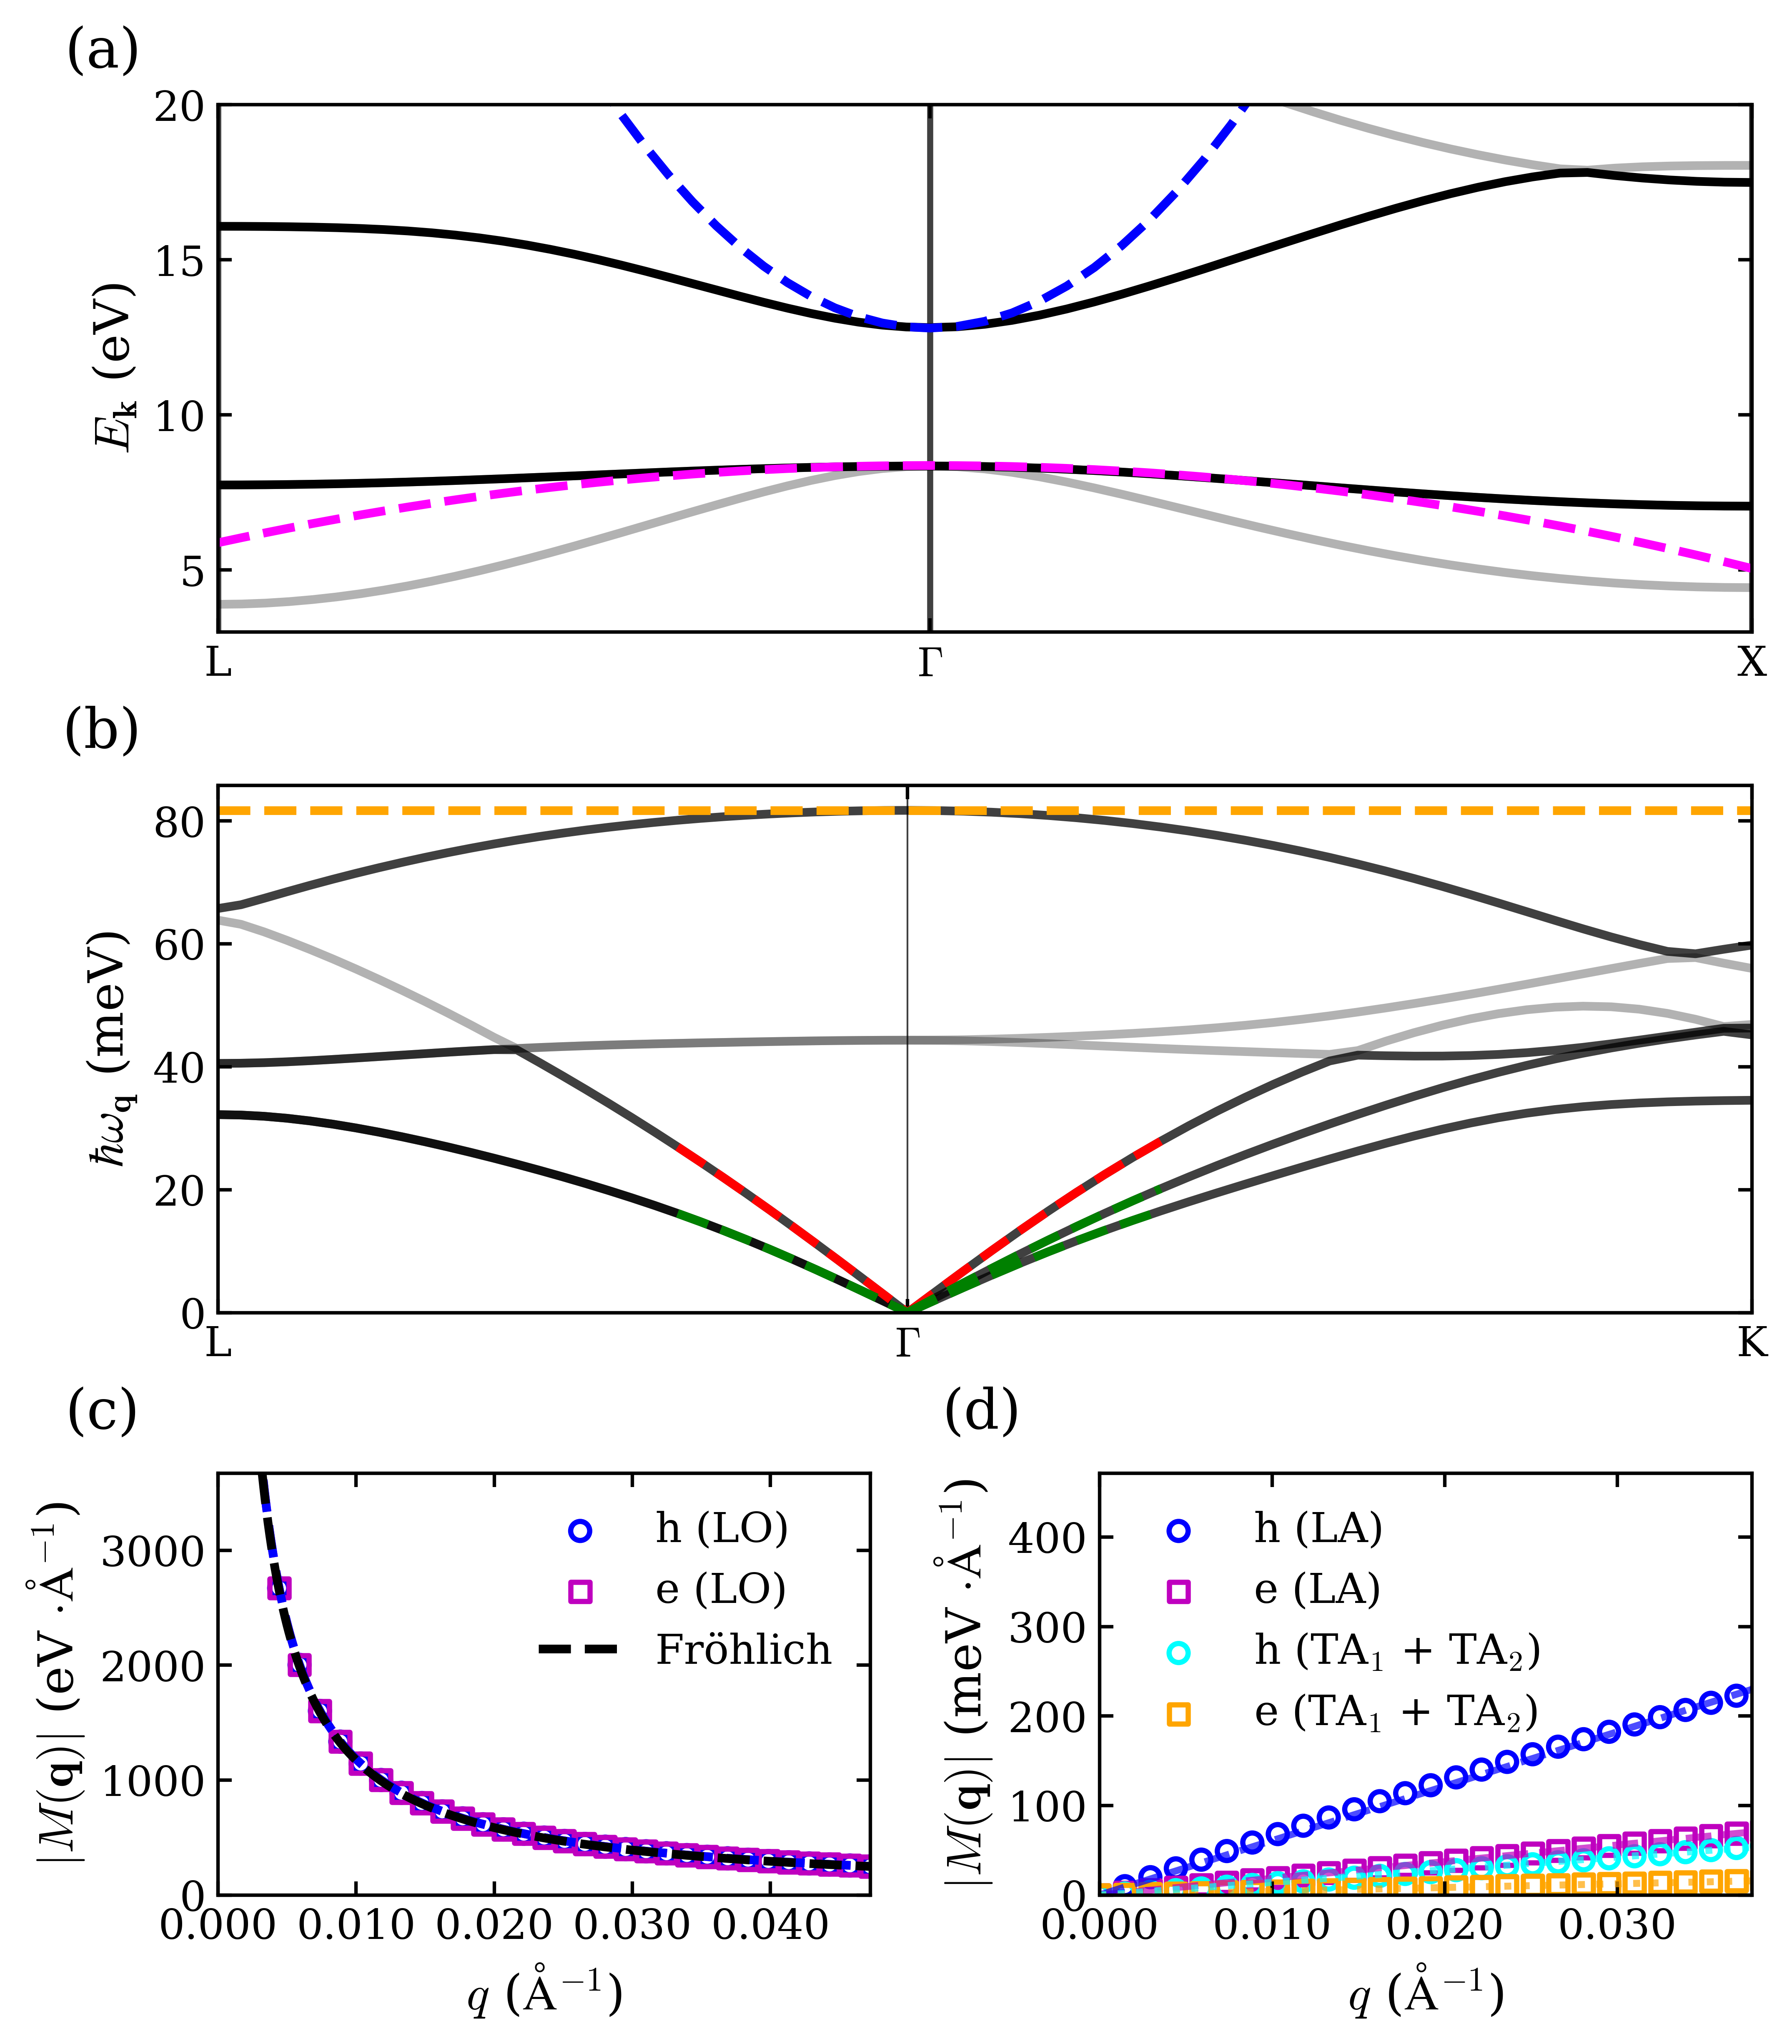

In [9]:
from pylab import *
from numpy import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numba
from scipy.optimize import curve_fit
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import matplotlib as mpl
from matplotlib import rcParams


scale = 1.0

main_text_size = 14
tick_label_size = 12
legend_size = 12
lab_size = 16

# Set publication quality parameters with scaled fonts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif', 'Computer Modern Roman', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['font.sans-serif'] = ['CMU Sans Serif', 'Computer Modern Sans Serif', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern for math (matches CMU Serif)

plt.rcParams['font.size'] = 12 * scale
plt.rcParams['axes.labelsize'] = 12 * scale
plt.rcParams['xtick.labelsize'] = 10 * scale
plt.rcParams['ytick.labelsize'] = 10 * scale
plt.rcParams['legend.fontsize'] = 11 * scale
plt.rcParams['axes.linewidth'] = 1.5 * scale
plt.rcParams['xtick.major.width'] = 1.5 * scale
plt.rcParams['ytick.major.width'] = 1.5 * scale
plt.rcParams['xtick.major.size'] = 6 * scale
plt.rcParams['ytick.major.size'] = 6 * scale
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.formatter.use_mathtext'] = True

plt.rcParams['font.size'] = main_text_size
plt.rcParams['axes.labelsize'] = main_text_size
plt.rcParams['xtick.labelsize'] = tick_label_size
plt.rcParams['ytick.labelsize'] = tick_label_size
plt.rcParams['legend.fontsize'] = legend_size
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

fig_width_inches = 7.05
aspect_ratio = 16/14
fig_height_inches = fig_width_inches * aspect_ratio


fig = plt.figure(figsize=(fig_width_inches, fig_height_inches), constrained_layout=True)
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.8])

# Panel (a) - Electronic band structure (Row 1, spans both columns)
ax1 = fig.add_subplot(gs[0, :])
V = 130.1037
Nc = 1
w = 0.0030977429327
pek = 1/3.3 - 1/11.3

data = np.loadtxt("mgo/MgO_bands.dat.gnu")

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

# Find the CBM and VBM band indices at Gamma point
gamma_idx = np.argmin(np.abs(k - 1.1124))
E_CBM = 12.8
E_VBM = 8.37

# Find which bands are closest to CBM and VBM energies at Gamma
cbm_band_idx = np.argmin(np.abs(bands[:, gamma_idx] - E_CBM))
vbm_band_idx = np.argmin(np.abs(bands[:, gamma_idx] - E_VBM))+1

# Plot bands with different opacity
for band in range(len(bands)):
    if band == cbm_band_idx or band == vbm_band_idx:
        ax1.plot(k, bands[band, :], linewidth=2.5*scale, alpha=1.0, color='black')
    else:
        ax1.plot(k, bands[band, :], linewidth=2.5*scale, alpha=0.3, color='black')

ax1.set_xlim(min(k), max(k))

ax1.axvline(0.5, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(1.1124, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(1.8195, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(2.1730, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(2.4230, linewidth=1.75*scale, color='k', alpha=0.75)

ax1.set_xticks([0, 0.5, 1.1124, 1.8195, 2.1730, 2.4230])
ax1.set_xticklabels(['W','L',r'$\Gamma$', 'X', 'W', 'K'])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax1.set_ylabel(r"$E_{\mathbf{k}}$ (eV)") 
ax1.set_ylim([3,20])


# MgO parameters
m_e = 0.34
m_h = 5.0
E_CBM = 12.8
E_VBM = 8.37
gamma_x = 1.1124

# MgO lattice parameter 
a_angstrom = 3.010
a_bohr = a_angstrom * 1.8897259886

# High symmetry point positions on the path
k_at_L = 0.5
k_at_X = 1.8195

# Path distances in QE plot
path_L_to_Gamma = gamma_x - k_at_L
path_Gamma_to_X = k_at_X - gamma_x

# For MgO (fcc structure), reciprocal space distances (units of 2π/a):
L_to_Gamma_reciprocal = (np.sqrt(3)/2) * (2*np.pi/a_bohr)
Gamma_to_X_reciprocal = 1.0 * (2*np.pi/a_bohr)

# Scaling factors to convert path distance to real k-space
scale_left = L_to_Gamma_reciprocal / path_L_to_Gamma
scale_right = Gamma_to_X_reciprocal / path_Gamma_to_X

hartree_to_eV = 27.2114

# For k < gamma_x (L side)
k_left = k[(k >= k_at_L) & (k <= gamma_x)]
k_real_left = scale_left * np.abs(k_left - gamma_x)
E_CB_left = E_CBM + (hartree_to_eV / (2 * m_e)) * k_real_left**2
E_VB_left = E_VBM - (hartree_to_eV / (2 * m_h)) * k_real_left**2

# For k > gamma_x (X side)
k_right = k[(k >= gamma_x) & (k <= k_at_X)]
k_real_right = scale_right * np.abs(k_right - gamma_x)
E_CB_right = E_CBM + (hartree_to_eV / (2 * m_e)) * k_real_right**2
E_VB_right = E_VBM - (hartree_to_eV / (2 * m_h)) * k_real_right**2

# Combine for plotting
k_combined = np.concatenate([k_left, k_right[1:]])
E_CB_combined = np.concatenate([E_CB_left, E_CB_right[1:]])
E_VB_combined = np.concatenate([E_VB_left, E_VB_right[1:]])


ax1.plot(k_combined, E_CB_combined, linestyle='dashed', linewidth=2.5*scale,
         color='blue', label=f'CB (m*={m_e})')
ax1.plot(k_combined, E_VB_combined, linestyle='dashed', linewidth=2.5*scale,
         color='magenta', label=f'VB (m*={m_h})')

ax1.set_xlim([0.5, 1.8195])

# Add label (a) outside the plot
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (b) - Phonon dispersion (Row 2, spans both columns)
ax2 = fig.add_subplot(gs[1, :])
data = np.loadtxt("mgo/MgO.freq.gp")

nbands = data.shape[1]

# For MgO, identify optical modes at Gamma
gamma_idx_phonon = 120
frequencies_at_gamma = data[gamma_idx_phonon, 1:] * 0.00012 * 1000

# Find non-zero frequency modes (optical modes)
optical_mode_mask = frequencies_at_gamma > 10
optical_frequencies = frequencies_at_gamma[optical_mode_mask]
optical_indices = np.where(optical_mode_mask)[0]

# Sort optical modes by frequency
sorted_optical_indices = optical_indices[np.argsort(optical_frequencies)]

# In MgO with 2 atoms per unit cell, there are 6 modes total:
# 3 acoustic (LA, TA1, TA2) and 3 optical (TO1, TO2, LO)
if len(sorted_optical_indices) >= 2:
    to_mode_indices = sorted_optical_indices[:2]
else:
    to_mode_indices = sorted_optical_indices

# Plot phonon bands with different opacity
for band in range(1, nbands):
    if band - 1 in to_mode_indices:
        ax2.plot(data[:, 0], data[:, band]*0.00012*1000, linewidth=2.5*scale, alpha=0.3, color='black')
    else:
        ax2.plot(data[:, 0], data[:, band]*0.00012*1000, linewidth=2.5*scale, alpha=0.75, color='black')

# High symmetry k-points
ax2.axvline(x=data[0, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[30, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[60, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[90, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[120, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[150, 0], linewidth=0.5*scale, color='k', alpha=0.75)

ax2.set_xticks([0, data[30, 0], data[60, 0], data[90, 0], data[120, 0], data[150,0]])
ax2.set_xticklabels([r'$\Gamma$', 'X', 'W','L', r'$\Gamma$','K'])
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax2.set_ylabel(r"$\hbar \omega_{\mathbf{q}}$ (meV)")
ax2.set_xlim(data[90, 0], data[150, 0])
ax2.set_ylim(0, )
ax2.axhline(data[0, -1]*0.00012*1000, color='orange', linestyle='dashed', linewidth=2.5*scale)

# LA mode in RED (dashed)
ax2.plot(data[110:121, 0], data[110:121, 3]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='red')
ax2.plot(data[120:130, 0], data[120:130, 3]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='red')

# TA1 mode in GREEN (dashed)
ax2.plot(data[110:121, 0], data[110:121, 1]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')
ax2.plot(data[120:130, 0], data[120:130, 1]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')

# TA2 mode in GREEN (dashed)
ax2.plot(data[110:121, 0], data[110:121, 2]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')
ax2.plot(data[120:130, 0], data[120:130, 2]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')

# Add label (b) outside the plot
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (c) - LO MODE (Row 3, left column)
ax3 = fig.add_subplot(gs[2, 0])
qx = np.loadtxt("mgo/dqpath1.txt")[:,0]
qy = np.loadtxt("mgo/dqpath1.txt")[:,1]
qz = np.loadtxt("mgo/dqpath1.txt")[:,2]

omega = np.loadtxt("mgo/dvb_LO.txt")[:,5]/27.211386245988/1000
vb_LO = np.loadtxt("mgo/dvb_LO.txt")[:,6]/27.211386245988/1000 *np.sqrt(2*abs(omega)*73361.40434044455)/0.529177
cb_LO = np.loadtxt("mgo/dcb_LO.txt")[:,6]/27.211386245988/1000 *np.sqrt(2*abs(omega)*73361.40434044455)/0.529177

qmag = np.zeros(len(qx))
for i in range(len(qx)):
    a,b,c = qx[i],qy[i],qz[i]
    qmag[i] = np.sqrt(a**2 + b**2 + c**2)*(2*np.pi)/5.6877 /0.529177

qmag1 = np.arange(1,602)
ax3.scatter(qmag[1:100], (vb_LO[1:100]*27.211386245988*np.sqrt(3)), label=r'h (LO)',
            marker='o', facecolors='none', edgecolors='blue', s=30*scale**2, linewidth=1.5*scale)
ax3.scatter(qmag[1:100], (cb_LO[1:100]*27.211386245988), label=r'e (LO)',
            marker='s', facecolors='none', edgecolors='m', s=30*scale**2, linewidth=1.5*scale)

ax3.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax3.set_xlim([0.0, 0.025/0.529177])
ax3.set_ylim([0.0, 90*np.sqrt(2*abs(omega[1])*73361.40434044455)/0.529177 +50])
ax3.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")                           
ax3.set_ylabel(r"$|M(\mathbf{q})|$ (eV $\cdot \mathrm{\AA}^{-1}$)")   

def func(x, D):
    return (D/x)

popt, pcov = curve_fit(func, qmag[1:10], cb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(qmag[1], qmag[200], 5000), func(np.linspace(qmag[1], qmag[200], 5000), *popt)*27.211386245988,
         linestyle='dashed', color='m', linewidth=2.5*scale)

popt, pcov = curve_fit(func, qmag[1:10], vb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(qmag[1], qmag[200], 5000), func(np.linspace(qmag[1], qmag[200], 5000), *popt)*27.211386245988*np.sqrt(3),
         linestyle='dashed', color='b', linewidth=2.5*scale)

V = 130.1037
Nc = 1
w = 0.0030977429327
pek = 1/3.3 - 1/11.3
q_Fr = np.linspace(0.000001, qmag[100], 10000)
froh = np.sqrt((4*np.pi/(1*V))*pek*0.5*w)*np.sqrt(2*w*73361.40434044455)/0.529177
ax3.plot(q_Fr, froh/q_Fr *27.211386245988 /0.529177, label=r'Fröhlich', linewidth=2.5*scale, linestyle='dashed', color='black')
ax3.legend(loc='best', frameon=False)

# Add label (c) outside the plot
ax3.text(-0.12, 1.08, '(c)', transform=ax3.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (d) - Combined LA and TA MODES (Row 3, right column)
ax4 = fig.add_subplot(gs[2, 1])

# LA MODE
omega_LA = np.loadtxt("mgo/dcb_LA.txt")[:,5]/27.211386245988/1000
vb_LA = np.loadtxt("mgo/dvb_LA.txt")[:,6]/27.211386245988/1000 *np.sqrt(2*abs(omega_LA)*73361.40434044455)/0.529177
cb_LA = np.loadtxt("mgo/dcb_LA.txt")[:,6]/27.211386245988/1000 *np.sqrt(2*abs(omega_LA)*73361.40434044455)/0.529177

ax4.scatter(qmag[0:500], (vb_LA[0:500])*27.211386245988*1000, label=r'h (LA)',
            marker='o', facecolors='none', edgecolors='blue', s=30*scale**2, linewidth=1.5*scale)
ax4.scatter(qmag[0:500], (cb_LA[0:500])*27.211386245988*1000, label=r'e (LA)',
            marker='s', facecolors='none', edgecolors='m', s=30*scale**2, linewidth=1.5*scale)

# TA MODES
omega1 = np.loadtxt("mgo/dcb_TA1.txt")[:,5]/27.211386245988/1000
omega2 = np.loadtxt("mgo/dcb_TA2.txt")[:,5]/27.211386245988/1000

vb_TA = (np.loadtxt("mgo/dvb_TA1.txt")[:,6])/27.211386245988/1000 *np.sqrt(2*abs(omega1)*73361.40434044455)/0.529177
vb_TA = vb_TA + (np.loadtxt("mgo/dvb_TA2.txt")[:,6])/27.211386245988/1000 *np.sqrt(2*abs(omega2)*73361.40434044455)/0.529177
cb_TA = (np.loadtxt("mgo/dcb_TA1.txt")[:,6])/27.211386245988/1000 *np.sqrt(2*abs(omega1)*73361.40434044455)/0.529177
cb_TA = cb_TA + (np.loadtxt("mgo/dcb_TA2.txt")[:,6])/27.211386245988/1000 *np.sqrt(2*abs(omega2)*73361.40434044455)/0.529177

ax4.scatter(qmag[0:500], (vb_TA[0:500])*27.211386245988*1000, label=r'h (TA$_1$ + TA$_2$)',
            marker='o', facecolors='none', edgecolors='cyan', s=30*scale**2, linewidth=1.5*scale)
ax4.scatter(qmag[0:500], (cb_TA[0:500])*27.211386245988*1000, label=r'e (TA$_1$ + TA$_2$)',
            marker='s', facecolors='none', edgecolors='orange', s=30*scale**2, linewidth=1.5*scale)

ax4.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax4.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")                             
ax4.set_ylabel(r"$|M(\mathbf{q})|$ (meV $\cdot \mathrm{\AA}^{-1}$)")    

def func_linear(x, D):
    return D*x

# Fit LA modes
popt, pcov = curve_fit(func_linear, qmag[1:10], cb_LA[1:10], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dashed', color='m', linewidth=2.0*scale, alpha=0.7)

popt, pcov = curve_fit(func_linear, qmag[1:32], vb_LA[1:32], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dashed', color='blue', linewidth=2.0*scale, alpha=0.7)

# Fit TA modes
popt, pcov = curve_fit(func_linear, qmag[1:10], cb_TA[1:10], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dotted', color='orange', linewidth=2.0*scale, alpha=0.7)

popt, pcov = curve_fit(func_linear, qmag[1:32], vb_TA[1:32], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dotted', color='cyan', linewidth=2.0*scale, alpha=0.7)

ax4.set_xlim([0, 0.02/0.529177])
ax4.set_ylim([0, 170/0.529177+150])
ax4.legend(loc='best', frameon=False, ncol=1)

# Add label (d) outside the plot
ax4.text(-0.12, 1.08, '(d)', transform=ax4.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

plt.show()
#fig.savefig('mgo_es.pdf', format='pdf', bbox_inches='tight')

This is for CdS electronic structure

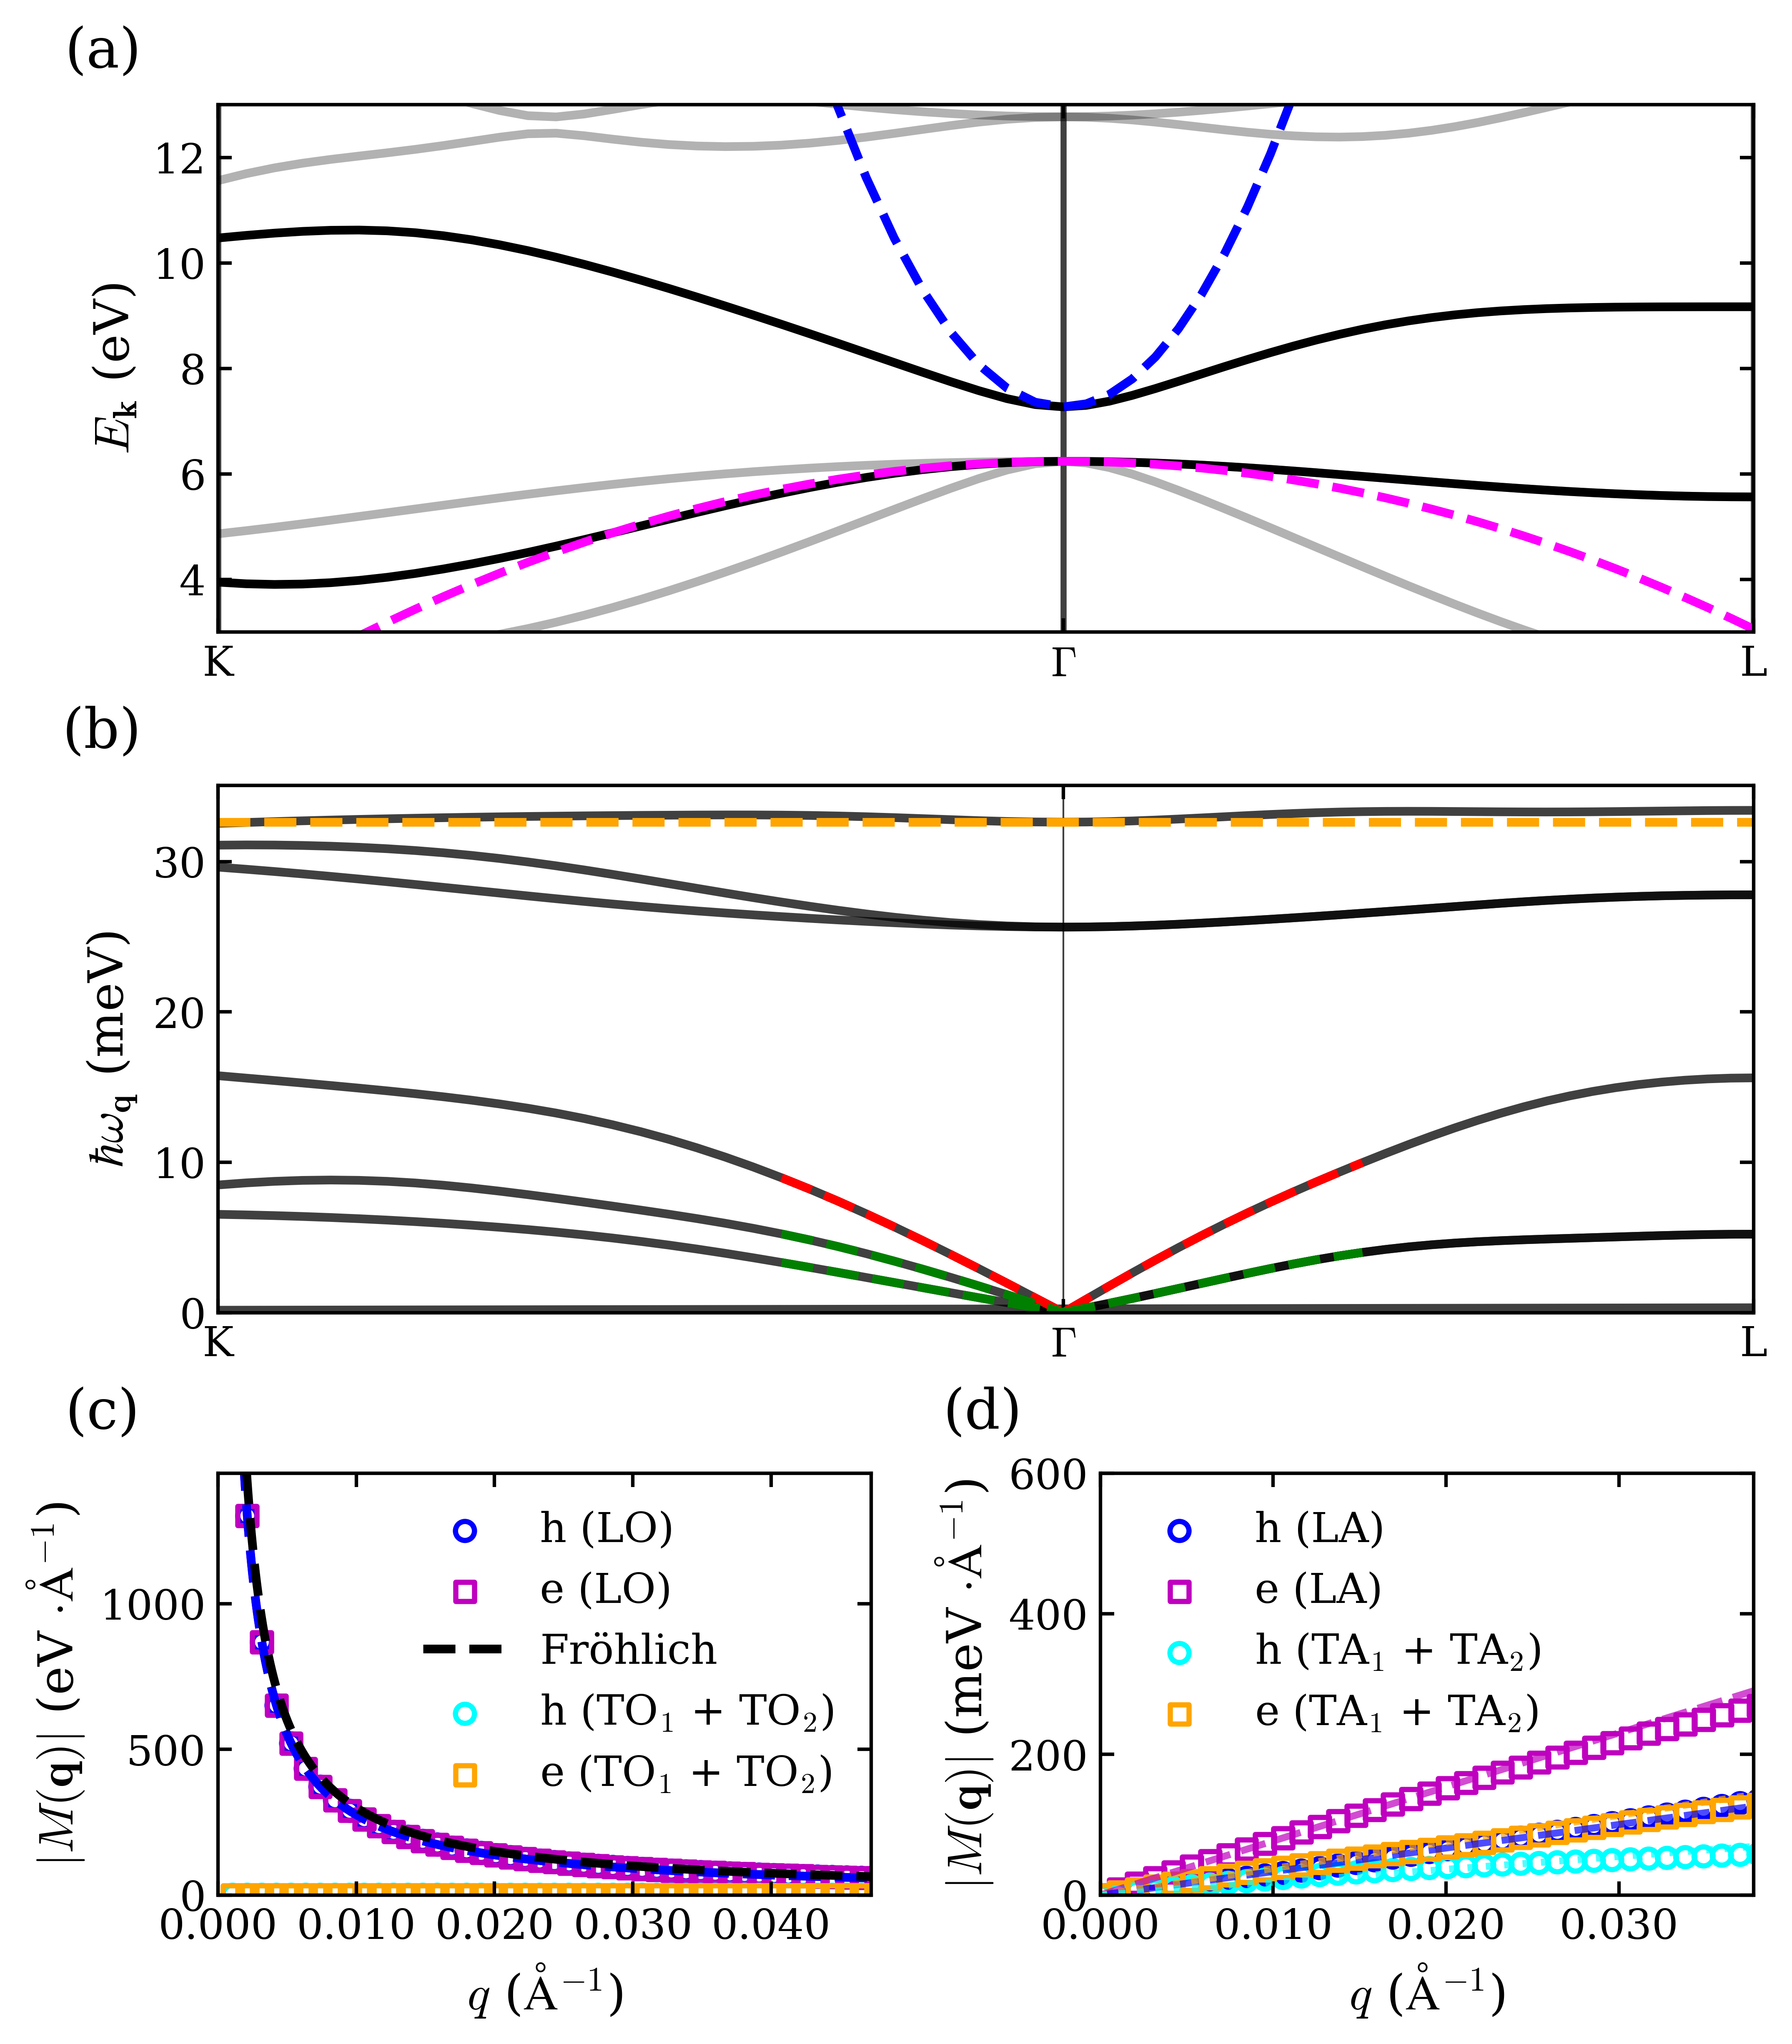

In [11]:
from pylab import *
from numpy import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numba
from scipy.optimize import curve_fit
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import matplotlib as mpl
from matplotlib import rcParams


scale = 1.0

main_text_size = 14
tick_label_size = 12
legend_size = 12
lab_size = 16

# Set publication quality parameters with scaled fonts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif', 'Computer Modern Roman', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['font.sans-serif'] = ['CMU Sans Serif', 'Computer Modern Sans Serif', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern for math (matches CMU Serif)

plt.rcParams['font.size'] = 12 * scale
plt.rcParams['axes.labelsize'] = 12 * scale
plt.rcParams['xtick.labelsize'] = 10 * scale
plt.rcParams['ytick.labelsize'] = 10 * scale
plt.rcParams['legend.fontsize'] = 11 * scale
plt.rcParams['axes.linewidth'] = 1.5 * scale
plt.rcParams['xtick.major.width'] = 1.5 * scale
plt.rcParams['ytick.major.width'] = 1.5 * scale
plt.rcParams['xtick.major.size'] = 6 * scale
plt.rcParams['ytick.major.size'] = 6 * scale
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.formatter.use_mathtext'] = True

plt.rcParams['font.size'] = main_text_size
plt.rcParams['axes.labelsize'] = main_text_size
plt.rcParams['xtick.labelsize'] = tick_label_size
plt.rcParams['ytick.labelsize'] = tick_label_size
plt.rcParams['legend.fontsize'] = legend_size
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

fig_width_inches = 7.05
aspect_ratio = 16/14
fig_height_inches = fig_width_inches * aspect_ratio


fig = plt.figure(figsize=(fig_width_inches, fig_height_inches), constrained_layout=True)
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.8])

# Panel (a) - Electronic band structure (Row 1, spans both columns)
ax1 = fig.add_subplot(gs[0, :])
V = 130.1037
Nc = 1
w = 0.0030977429327
pek = 1/3.3 - 1/11.3

data = np.loadtxt("cds/CdS_bands.dat.gnu")
k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

# Find the CBM and VBM band indices at Gamma point
gamma_idx = np.argmin(np.abs(k - 2.0607))
E_CBM = 7.270
E_VBM = 6.238

# Find which bands are closest to CBM and VBM energies at Gamma
cbm_band_idx = np.argmin(np.abs(bands[:, gamma_idx] - E_CBM))
vbm_band_idx = np.argmin(np.abs(bands[:, gamma_idx] - E_VBM))+1

# Plot bands with different opacity
for band in range(len(bands)):
    if band == cbm_band_idx or band == vbm_band_idx:
        ax1.plot(k, bands[band, :], linewidth=2.5*scale, alpha=1.0, color='black')
    else:
        ax1.plot(k, bands[band, :], linewidth=2.5*scale, alpha=0.3, color='black')

ax1.set_xlim(min(k), max(k))

ax1.axvline(1.3107, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(2.0607, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(2.6730, linewidth=1.75*scale, color='k', alpha=0.75)

ax1.set_xticks([1.3107, 2.0607, 2.6730])
ax1.set_xticklabels(['K', r'$\Gamma$', 'L'])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax1.set_ylabel(r"$E_{\mathbf{k}}$ (eV)")  
ax1.set_ylim([3,13])

# CdS parameters
m_e = 0.12
m_h = 2.01
E_CBM = 7.270
E_VBM = 6.238
gamma_x = 2.0607

# CdS lattice parameter (zinc blende structure)
a_angstrom = 4.20
a_bohr = a_angstrom * 1.8897259886

# High symmetry point positions on the path
k_at_K = 1.3107
k_at_L = 2.6730
total_path_length = k_at_L - k_at_K

# In reciprocal space (units of 2π/a):
# K is at (3/4, 3/4, 0) → |K-Γ| = (3√2/4) * 2π/a
# L is at (1/2, 1/2, 1/2) → |L-Γ| = (√3/2) * 2π/a
K_to_Gamma_reciprocal = (3*np.sqrt(2)/4) * (2*np.pi/a_bohr)
Gamma_to_L_reciprocal = (np.sqrt(3)/2) * (2*np.pi/a_bohr)

# Path distances in QE plot
path_K_to_Gamma = gamma_x - k_at_K
path_Gamma_to_L = k_at_L - gamma_x

# Scaling factors to convert path distance to real k-space (units: 1/bohr per path-unit)
scale_left = K_to_Gamma_reciprocal / path_K_to_Gamma
scale_right = Gamma_to_L_reciprocal / path_Gamma_to_L

hartree_to_eV = 27.2114

# For k < gamma_x (K side) -- k_real in 1/bohr
k_left = k[k <= gamma_x]
k_real_left = scale_left * np.abs(k_left - gamma_x)          # 1/bohr
E_CB_left = E_CBM + (hartree_to_eV / (2 * m_e)) * k_real_left**2
E_VB_left = E_VBM - (hartree_to_eV / (2 * m_h)) * k_real_left**2

# For k > gamma_x (L side) -- k_real in 1/bohr
k_right = k[k >= gamma_x]
k_real_right = scale_right * np.abs(k_right - gamma_x)        # 1/bohr
E_CB_right = E_CBM + (hartree_to_eV / (2 * m_e)) * k_real_right**2
E_VB_right = E_VBM - (hartree_to_eV / (2 * m_h)) * k_real_right**2

# Combine for plotting
k_combined = np.concatenate([k_left, k_right[1:]])
E_CB_combined = np.concatenate([E_CB_left, E_CB_right[1:]])
E_VB_combined = np.concatenate([E_VB_left, E_VB_right[1:]])

ax1.plot(k_combined, E_CB_combined, linestyle='dashed', linewidth=2.5*scale,
         color='blue', label=f'CB (m*={m_e})')
ax1.plot(k_combined, E_VB_combined, linestyle='dashed', linewidth=2.5*scale,
         color='magenta', label=f'VB (m*={m_h})')

ax1.set_xlim([1.3107, 2.673])

# Add label (a) outside the plot
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (b) - Phonon dispersion (Row 2, spans both columns)
ax2 = fig.add_subplot(gs[1, :])
data = np.loadtxt("cds/CdS.freq.gp")

nbands = data.shape[1]
for band in range(nbands):
    ax2.plot(data[:, 0], data[:, band]*0.00012*1000, linewidth=2.5*scale, alpha=0.75, color='black')

# High symmetry k-points
ax2.axvline(x=data[0, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[30, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[60, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[90, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[120, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[150, 0], linewidth=0.5*scale, color='k', alpha=0.75)

ax2.set_xticks([0, data[30, 0], data[60, 0], data[90, 0], data[120, 0], data[150,0]])
ax2.set_xticklabels([r'$\Gamma$', 'X', 'W', 'K', r'$\Gamma$', 'L'])
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax2.set_ylabel(r"$\hbar \omega_{\mathbf{q}}$ (meV)")
ax2.set_xlim(data[90, 0], data[150, 0])
ax2.set_ylim(0, )
ax2.axhline(data[0, -1]*0.00012*1000, color='orange', linestyle='dashed', linewidth=2.5*scale)

# LA mode in RED (dashed)
ax2.plot(data[110:121, 0], data[110:121, 3]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='red')
ax2.plot(data[120:134, 0], data[120:134, 3]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='red')

# TA1 mode in GREEN (dashed)
ax2.plot(data[110:121, 0], data[110:121, 1]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')
ax2.plot(data[120:134, 0], data[120:134, 1]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')

# TA2 mode in GREEN (dashed)
ax2.plot(data[110:121, 0], data[110:121, 2]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')
ax2.plot(data[120:134, 0], data[120:134, 2]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')

# Add label (b) outside the plot
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (c) - LO MODE (Row 3, left column)
ax3 = fig.add_subplot(gs[2, 0])
qx = np.loadtxt("cds/dqpath1.txt")[:,0]
qy = np.loadtxt("cds/dqpath1.txt")[:,1]
qz = np.loadtxt("cds/dqpath1.txt")[:,2]

omega = np.loadtxt("cds/dvb_LO.txt")[:,5]/27.211386245988/1000
vb_LO = np.loadtxt("cds/dvb_LO.txt")[:,6]/27.211386245988/1000*np.sqrt(2*abs(omega)*744.292*353.7357)/0.529177
cb_LO = np.loadtxt("cds/dcb_LO.txt")[:,6]/27.211386245988/1000*np.sqrt(2*abs(omega)*744.292*353.7357)/0.529177

qmag = np.zeros(len(qx))
for i in range(len(qx)):
    a,b,c = qx[i],qy[i],qz[i]
    qmag[i] = np.sqrt(a**2 + b**2 + c**2)*(2*np.pi)/7.9384 /0.529177

qmag1 = np.arange(1,602)
ax3.scatter(qmag[1:100], (vb_LO[1:100]*27.211386245988*np.sqrt(3)), label=r'h (LO)',
            marker='o', facecolors='none', edgecolors='blue', s=30*scale**2, linewidth=1.5*scale)
ax3.scatter(qmag[1:100], (cb_LO[1:100]*27.211386245988), label=r'e (LO)',
            marker='s', facecolors='none', edgecolors='m', s=30*scale**2, linewidth=1.5*scale)

ax3.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax3.set_xlim([0.0, 0.025/0.529177])
ax3.set_ylim([0.0, 30*np.sqrt(2*abs(omega[1])*744.292*353.7357)/0.529177])
ax3.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")                           
ax3.set_ylabel(r"$|M(\mathbf{q})|$ (eV $\cdot \mathrm{\AA}^{-1}$)")   

def func(x, D):
    return (D/x)

popt, pcov = curve_fit(func, qmag[1:10], cb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(qmag[1], qmag[200], 5000), func(np.linspace(qmag[1], qmag[200], 5000), *popt)*27.211386245988,
         linestyle='dashed', color='m', linewidth=2.5*scale)

popt, pcov = curve_fit(func, qmag[1:10], vb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(qmag[1], qmag[200], 5000), func(np.linspace(qmag[1], qmag[200], 5000), *popt)*27.211386245988*np.sqrt(3),
         linestyle='dashed', color='b', linewidth=2.5*scale)

V = 353.7357
Nc = 1
w = 0.00124948
pek = 1/6.2 - 1/10.4
q_Fr = np.linspace(0.000001, qmag[100], 10000)
froh = np.sqrt((4*np.pi/(1*V))*pek*0.5*w)/0.529177 * np.sqrt(2*w*744.292*353.7357)/0.529177
ax3.plot(q_Fr, froh/q_Fr *27.211386245988, label=r'Fröhlich', linewidth=2.5*scale, linestyle='dashed', color='black')

omega1 = np.loadtxt("cds/dvb_TO1.txt")[:,5]/27.211386245988/1000
omega2 = np.loadtxt("cds/dvb_TO2.txt")[:,5]/27.211386245988/1000
vb_TO = (np.loadtxt("cds/dvb_TO1.txt")[:,6])/27.211386245988/1000*np.sqrt(2*abs(omega1)*744.292*353.7357)/0.529177
vb_TO = vb_TO + (np.loadtxt("cds/dvb_TO2.txt")[:,6])/27.211386245988/1000*np.sqrt(2*abs(omega2)*744.292*353.7357)/0.529177
cb_TO = (np.loadtxt("cds/dcb_TO1.txt")[:,6])/27.211386245988/1000*np.sqrt(2*abs(omega1)*744.292*353.7357)/0.529177
cb_TO = cb_TO + (np.loadtxt("cds/dcb_TO2.txt")[:,6])/27.211386245988/1000*np.sqrt(2*abs(omega2)*744.292*353.7357)/0.529177

ax3.scatter(qmag[1:100], (vb_TO[1:100]*27.211386245988), label=r'h (TO$_1$ + TO$_2$)',
            marker='o', facecolors='none', edgecolors='cyan', s=30*scale**2, linewidth=1.5*scale)
ax3.scatter(qmag[1:100], (cb_TO[1:100]*27.211386245988), label=r'e (TO$_1$ + TO$_2$)',
            marker='s', facecolors='none', edgecolors='orange', s=30*scale**2, linewidth=1.5*scale)

ax3.legend(loc='best', frameon=False)

# Add label (c) outside the plot
ax3.text(-0.12, 1.08, '(c)', transform=ax3.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (d) - Combined LA and TA MODES (Row 3, right column)
ax4 = fig.add_subplot(gs[2, 1])

# LA MODE
omega_LA = np.loadtxt("cds/dcb_LA.txt")[:,5]/27.211386245988/1000
vb_LA = np.loadtxt("cds/dvb_LA.txt")[:,6]/27.211386245988/1000 *np.sqrt(2*abs(omega_LA)*744.292*353.7357)/0.529177
cb_LA = np.loadtxt("cds/dcb_LA.txt")[:,6]/27.211386245988/1000 *np.sqrt(2*abs(omega_LA)*744.292*353.7357)/0.529177

ax4.scatter(qmag[0:500], (vb_LA[0:500])*27.211386245988*1000, label=r'h (LA)',
            marker='o', facecolors='none', edgecolors='blue', s=30*scale**2, linewidth=1.5*scale)
ax4.scatter(qmag[0:500], (cb_LA[0:500])*27.211386245988*1000, label=r'e (LA)',
            marker='s', facecolors='none', edgecolors='m', s=30*scale**2, linewidth=1.5*scale)

# TA MODES
omega1 = np.loadtxt("cds/dcb_TA1.txt")[:,5]/27.211386245988/1000
omega2 = np.loadtxt("cds/dcb_TA2.txt")[:,5]/27.211386245988/1000

vb_TA = (np.loadtxt("cds/dvb_TA1.txt")[:,6])/27.211386245988/1000 *np.sqrt(2*abs(omega1)*744.292*353.7357)/0.529177
vb_TA = vb_TA + (np.loadtxt("cds/dvb_TA2.txt")[:,6])/27.211386245988/1000 *np.sqrt(2*abs(omega2)*744.292*353.7357)/0.529177
cb_TA = (np.loadtxt("cds/dcb_TA1.txt")[:,6])/27.211386245988/1000 *np.sqrt(2*abs(omega1)*744.292*353.7357)/0.529177
cb_TA = cb_TA + (np.loadtxt("cds/dcb_TA2.txt")[:,6])/27.211386245988/1000 *np.sqrt(2*abs(omega2)*744.292*353.7357)/0.529177

ax4.scatter(qmag[0:500], (vb_TA[0:500])*27.211386245988*1000, label=r'h (TA$_1$ + TA$_2$)',
            marker='o', facecolors='none', edgecolors='cyan', s=30*scale**2, linewidth=1.5*scale)
ax4.scatter(qmag[0:500], (cb_TA[0:500])*27.211386245988*1000, label=r'e (TA$_1$ + TA$_2$)',
            marker='s', facecolors='none', edgecolors='orange', s=30*scale**2, linewidth=1.5*scale)

ax4.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax4.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")                             
ax4.set_ylabel(r"$|M(\mathbf{q})|$ (meV $\cdot \mathrm{\AA}^{-1}$)")    

def func_linear(x, D):
    return D*x

# Fit LA modes
popt, pcov = curve_fit(func_linear, qmag[1:10], cb_LA[1:10], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dashed', color='m', linewidth=2.0*scale, alpha=0.7)

popt, pcov = curve_fit(func_linear, qmag[1:32], vb_LA[1:32], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dashed', color='blue', linewidth=2.0*scale, alpha=0.7)

# Fit TA modes
popt, pcov = curve_fit(func_linear, qmag[1:10], cb_TA[1:10], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dotted', color='orange', linewidth=2.0*scale, alpha=0.7)

popt, pcov = curve_fit(func_linear, qmag[1:32], vb_TA[1:32], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dotted', color='cyan', linewidth=2.0*scale, alpha=0.7)

ax4.set_xlim([0, 0.02/0.529177])
ax4.set_ylim([0, 600])
ax4.legend(loc='best', frameon=False, ncol=1)

# Add label (d) outside the plot
ax4.text(-0.12, 1.08, '(d)', transform=ax4.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

plt.show()

This is for AgCl electronic structure

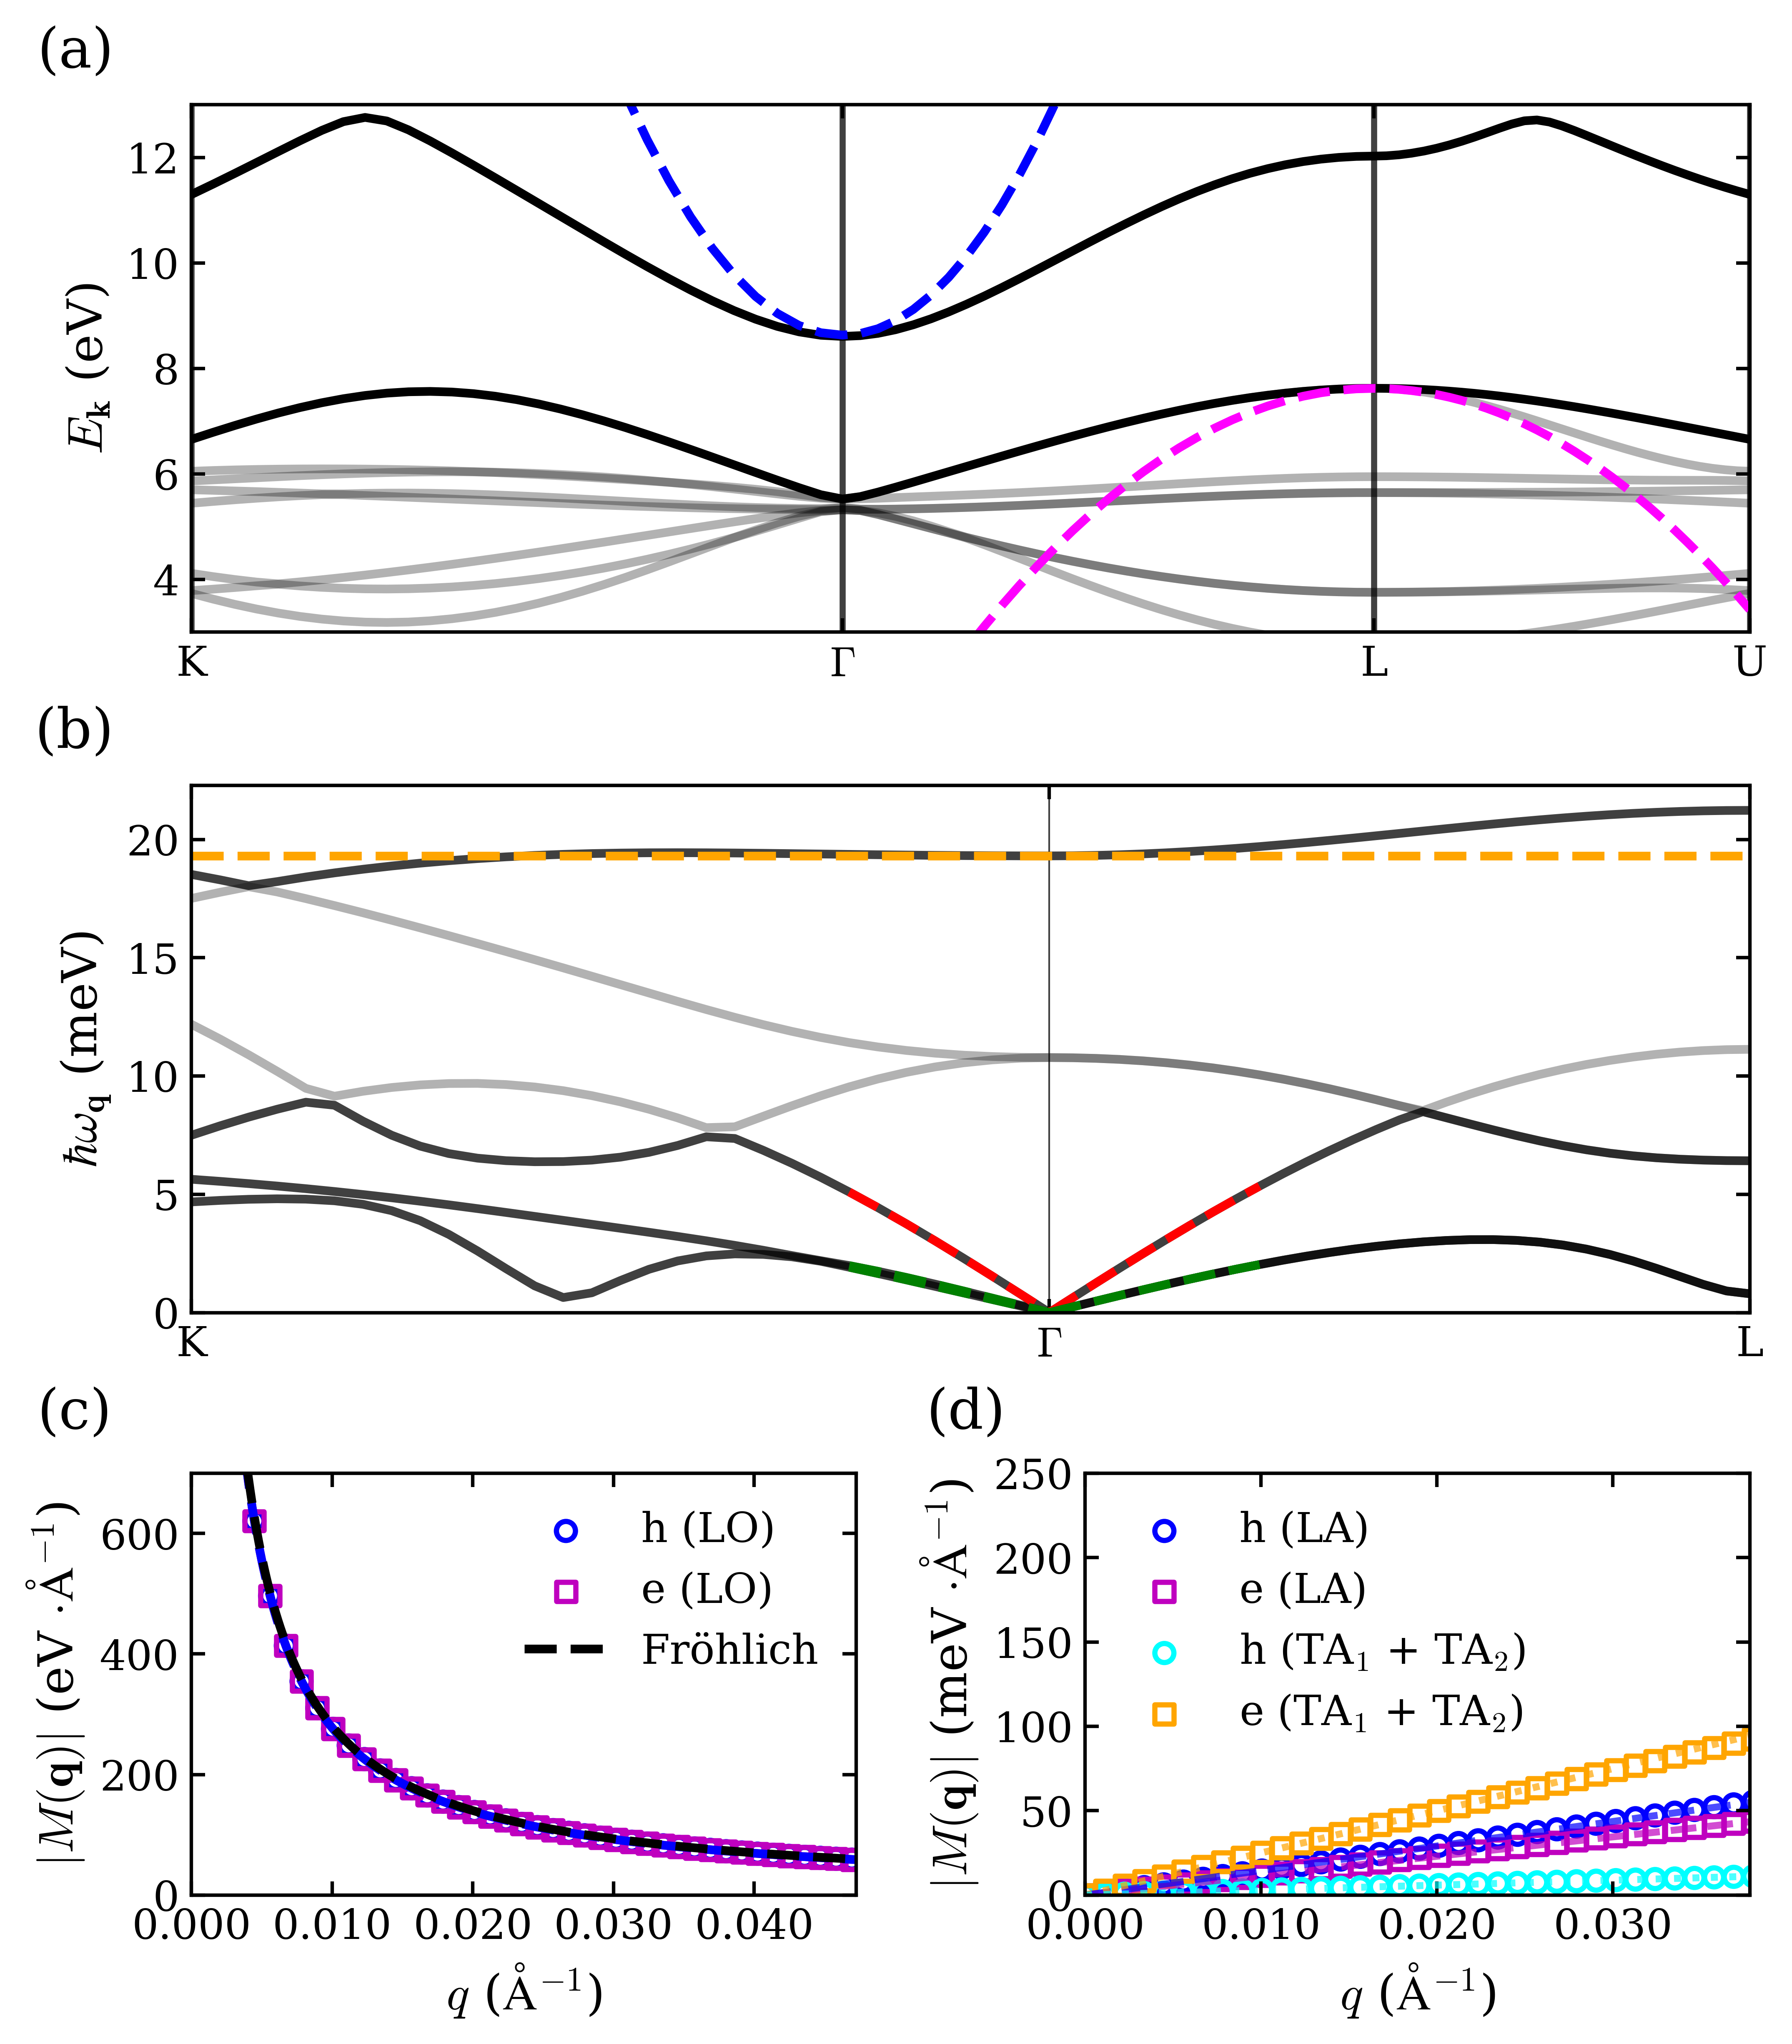

In [11]:
from pylab import *
from numpy import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numba
from scipy.optimize import curve_fit
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import matplotlib as mpl
from matplotlib import rcParams


scale = 1.0

main_text_size = 14
tick_label_size = 12
legend_size = 12
lab_size = 16

# Set publication quality parameters with scaled fonts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif', 'Computer Modern Roman', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['font.sans-serif'] = ['CMU Sans Serif', 'Computer Modern Sans Serif', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern for math (matches CMU Serif)

plt.rcParams['font.size'] = 12 * scale
plt.rcParams['axes.labelsize'] = 12 * scale
plt.rcParams['xtick.labelsize'] = 10 * scale
plt.rcParams['ytick.labelsize'] = 10 * scale
plt.rcParams['legend.fontsize'] = 11 * scale
plt.rcParams['axes.linewidth'] = 1.5 * scale
plt.rcParams['xtick.major.width'] = 1.5 * scale
plt.rcParams['ytick.major.width'] = 1.5 * scale
plt.rcParams['xtick.major.size'] = 6 * scale
plt.rcParams['ytick.major.size'] = 6 * scale
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.formatter.use_mathtext'] = True

plt.rcParams['font.size'] = main_text_size
plt.rcParams['axes.labelsize'] = main_text_size
plt.rcParams['xtick.labelsize'] = tick_label_size
plt.rcParams['ytick.labelsize'] = tick_label_size
plt.rcParams['legend.fontsize'] = legend_size
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

fig_width_inches = 7.05
aspect_ratio = 16/14
fig_height_inches = fig_width_inches * aspect_ratio


fig = plt.figure(figsize=(fig_width_inches, fig_height_inches), constrained_layout=True)
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.8])

# Panel (a) - Electronic band structure (Row 1, spans both columns)
ax1 = fig.add_subplot(gs[0, :])
V = 130.1037
Nc = 1
w = 0.0030977429327
pek = 1/3.3 - 1/11.3

data = np.loadtxt("agcl/AgCl_bands.dat.gnu")

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

# Find the CBM and VBM band indices at Gamma point
gamma_idx = np.argmin(np.abs(k - 2.0607))
L_idx = np.argmin(np.abs(k - 2.6730))

E_CBM = 8.631
E_VBM = 7.62132

# Find which bands are closest to CBM and VBM energies at Gamma
cbm_band_idx = np.argmin(np.abs(bands[:, gamma_idx] - E_CBM))
vbm_band_idx = np.argmin(np.abs(bands[:, L_idx] - E_VBM))+1

# Plot bands with different opacity
for band in range(len(bands)):
    if band == cbm_band_idx or band == vbm_band_idx:
        ax1.plot(k, bands[band, :], linewidth=2.5*scale, alpha=1.0, color='black')
    else:
        ax1.plot(k, bands[band, :], linewidth=2.5*scale, alpha=0.3, color='black')

ax1.set_xlim(min(k), max(k))

ax1.axvline(1.3107, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(2.0607, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(2.6730, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(3.106, linewidth=1.75*scale, color='k', alpha=0.75)

ax1.set_xticks([1.3107, 2.0607, 2.6730, 3.106])
ax1.set_xticklabels(['K', r'$\Gamma$', 'L', 'U'])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax1.set_ylabel(r"$E_{\mathbf{k}}$ (eV)")  
ax1.set_ylim([3, 13])

# AgCl parameters
m_e = 0.26
m_h = 0.85
E_CBM = 8.631
E_VBM = 7.62132
gamma_x = 2.0607
L_x = 2.6730

# AgCl lattice parameter
a_angstrom = 3.976
a_bohr = a_angstrom * 1.8897259886

# High symmetry point positions on the path
k_at_K = 1.3107
k_at_U = 3.106

hartree_to_eV = 27.2114

# Path distances in QE plot
path_K_to_Gamma = gamma_x - k_at_K
path_Gamma_to_L = L_x - gamma_x

K_to_Gamma_reciprocal = (3*np.sqrt(2)/4) * (2*np.pi/a_bohr)
Gamma_to_L_reciprocal = (np.sqrt(3)/2) * (2*np.pi/a_bohr)

# Scaling factors to convert path distance to real k-space
scale_CB_left = K_to_Gamma_reciprocal / path_K_to_Gamma
scale_CB_right = Gamma_to_L_reciprocal / path_Gamma_to_L

# For k < gamma_x (K side)
k_CB_left = k[(k >= k_at_K) & (k <= gamma_x)]
k_real_CB_left = scale_CB_left * np.abs(k_CB_left - gamma_x)
E_CB_left = E_CBM + (hartree_to_eV / (2 * m_e)) * k_real_CB_left**2

# For k > gamma_x (L side)
k_CB_right = k[(k >= gamma_x) & (k <= k_at_U)]
k_real_CB_right = scale_CB_right * np.abs(k_CB_right - gamma_x)
E_CB_right = E_CBM + (hartree_to_eV / (2 * m_e)) * k_real_CB_right**2

path_Gamma_to_L_VB = L_x - gamma_x
path_L_to_U = k_at_U - L_x

L_to_U_reciprocal = (np.sqrt(6)/4) * (2*np.pi/a_bohr)

scale_VB_left = Gamma_to_L_reciprocal / path_Gamma_to_L_VB
scale_VB_right = L_to_U_reciprocal / path_L_to_U

k_VB_left = k[(k >= gamma_x) & (k <= L_x)]
k_real_VB_left = scale_VB_left * np.abs(k_VB_left - L_x)
E_VB_left = E_VBM - (hartree_to_eV / (2 * m_h)) * k_real_VB_left**2

k_VB_right = k[(k >= L_x) & (k <= k_at_U)]
k_real_VB_right = scale_VB_right * np.abs(k_VB_right - L_x)
E_VB_right = E_VBM - (hartree_to_eV / (2 * m_h)) * k_real_VB_right**2

# Combine for plotting
k_CB_combined = np.concatenate([k_CB_left, k_CB_right[1:]])
E_CB_combined = np.concatenate([E_CB_left, E_CB_right[1:]])

k_VB_combined = np.concatenate([k_VB_left, k_VB_right[1:]])
E_VB_combined = np.concatenate([E_VB_left, E_VB_right[1:]])

ax1.plot(k_CB_combined, E_CB_combined, linestyle='dashed', linewidth=2.5*scale, color='blue')
ax1.plot(k_VB_combined, E_VB_combined, linestyle='dashed', linewidth=2.5*scale, color='magenta')

ax1.set_xlim([1.3107, 3.106])

# Add label (a) outside the plot
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (b) - Phonon dispersion (Row 2, spans both columns)
ax2 = fig.add_subplot(gs[1, :])
data = np.loadtxt("agcl/AgCl.freq.gp")

nbands = data.shape[1]

# For AgCl, identify optical modes at Gamma
gamma_idx_phonon = 120
frequencies_at_gamma = data[gamma_idx_phonon, 1:] * 0.00012 * 1000

# Find non-zero frequency modes (optical modes)
optical_mode_mask = frequencies_at_gamma > 5
optical_frequencies = frequencies_at_gamma[optical_mode_mask]
optical_indices = np.where(optical_mode_mask)[0]

# Sort optical modes by frequency
sorted_optical_indices = optical_indices[np.argsort(optical_frequencies)]

# In AgCl with 2 atoms per unit cell, there are 6 modes total:
# 3 acoustic (LA, TA1, TA2) and 3 optical (TO1, TO2, LO)
if len(sorted_optical_indices) >= 2:
    to_mode_indices = sorted_optical_indices[:2]
else:
    to_mode_indices = sorted_optical_indices

# Plot phonon bands with different opacity
for band in range(1, nbands):
    if band - 1 in to_mode_indices:
        ax2.plot(data[:, 0], data[:, band]*0.00012*1000, linewidth=2.5*scale, alpha=0.3, color='black')
    else:
        ax2.plot(data[:, 0], data[:, band]*0.00012*1000, linewidth=2.5*scale, alpha=0.75, color='black')

# High symmetry k-points
ax2.axvline(x=data[0, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[30, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[60, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[90, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[120, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[150, 0], linewidth=0.5*scale, color='k', alpha=0.75)

ax2.set_xticks([0, data[30, 0], data[60, 0], data[90, 0], data[120, 0], data[150, 0]])
ax2.set_xticklabels([r'$\Gamma$', 'X', 'W', 'K', r'$\Gamma$', 'L'])
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax2.set_ylabel(r"$\hbar \omega_{\mathbf{q}}$ (meV)")
ax2.set_xlim(data[90, 0], data[150, 0])
ax2.set_ylim(0, )
ax2.axhline(data[0, -1]*0.00012*1000, color='orange', linestyle='dashed', linewidth=2.5*scale)

# LA mode in RED (dashed)
ax2.plot(data[113:121, 0], data[113:121, 3]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='red')
ax2.plot(data[120:130, 0], data[120:130, 3]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='red')

# TA1 mode in GREEN (dashed)
ax2.plot(data[113:121, 0], data[113:121, 1]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')
ax2.plot(data[120:130, 0], data[120:130, 1]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')

# TA2 mode in GREEN (dashed)
ax2.plot(data[113:121, 0], data[113:121, 2]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')
ax2.plot(data[120:130, 0], data[120:130, 2]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')

# Add label (b) outside the plot
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (c) - LO MODE (Row 3, left column)
ax3 = fig.add_subplot(gs[2, 0])
qx = np.loadtxt("agcl/dqpath1.txt")[:, 0]
qy = np.loadtxt("agcl/dqpath1.txt")[:, 1]
qz = np.loadtxt("agcl/dqpath1.txt")[:, 2]

omega = np.loadtxt("agcl/dcb_LO.txt")[:, 5]/27.211386245988/1000
vb_LO = np.loadtxt("agcl/dvb_LO.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega)*871.049*299.8478)/0.529177
cb_LO = np.loadtxt("agcl/dcb_LO.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega)*871.049*299.8478)/0.529177

vb_LO = vb_LO[1::2]
cb_LO = cb_LO[0::2]

qmag = np.zeros(len(qx))
for i in range(len(qx)):
    a, b, c = qx[i], qy[i], qz[i]
    qmag[i] = np.sqrt(a**2 + b**2 + c**2)*(2*np.pi)/7.5129/0.529177

qmag1 = np.arange(1, 602)
ax3.scatter(qmag[1:100], (vb_LO[1:100]*27.211386245988*np.sqrt(2)), label=r'h (LO)',
            marker='o', facecolors='none', edgecolors='blue', s=30*scale**2, linewidth=1.5*scale)
ax3.scatter(qmag[1:100], (cb_LO[1:100]*27.211386245988), label=r'e (LO)',
            marker='s', facecolors='none', edgecolors='m', s=30*scale**2, linewidth=1.5*scale)

ax3.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax3.set_xlim([0.0, 0.025/0.529177])
ax3.set_ylim([0.0, 700])
ax3.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")                           
ax3.set_ylabel(r"$|M(\mathbf{q})|$ (eV $\cdot \mathrm{\AA}^{-1}$)")   

def func(x, D):
    return (D/x)

popt, pcov = curve_fit(func, qmag[1:10], cb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(qmag[1], qmag[200], 5000), func(np.linspace(qmag[1], qmag[200], 5000), *popt)*27.211386245988,
         linestyle='dashed', color='m', linewidth=2.5*scale)

popt, pcov = curve_fit(func, qmag[1:10], vb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(qmag[1], qmag[200], 5000), func(np.linspace(qmag[1], qmag[200], 5000), *popt)*27.211386245988*np.sqrt(2),
         linestyle='dashed', color='b', linewidth=2.5*scale)

V = 299.8478
Nc = 1
w = 0.0007364113064
pek = 1/4.91 - 1/15.74
q_Fr = np.linspace(0.000001, qmag[100], 10000)
froh = np.sqrt((4*np.pi/(1*V))*pek*0.5*w)/0.529177 * np.sqrt(2*w*871.049*299.8478)/0.529177
ax3.plot(q_Fr, froh/q_Fr*27.211386245988, label=r'Fröhlich', linewidth=2.5*scale, linestyle='dashed', color='black')

ax3.legend(loc='best', frameon=False)

# Add label (c) outside the plot
ax3.text(-0.12, 1.08, '(c)', transform=ax3.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (d) - Combined LA and TA MODES (Row 3, right column)
ax4 = fig.add_subplot(gs[2, 1])

# LA MODE
omega_LA = np.loadtxt("agcl/dvb_LA.txt")[:, 5]/27.211386245988/1000
vb_LA = np.loadtxt("agcl/dvb_LA.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega_LA)*871.049*299.8478)/0.529177
cb_LA = np.loadtxt("agcl/dcb_LA.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega_LA)*871.049*299.8478)/0.529177

vb_LA = vb_LA[1::2]
cb_LA = cb_LA[0::2]

ax4.scatter(qmag[0:500], (vb_LA[0:500])*27.211386245988*1000, label=r'h (LA)',
            marker='o', facecolors='none', edgecolors='blue', s=30*scale**2, linewidth=1.5*scale)
ax4.scatter(qmag[0:500], (cb_LA[0:500])*27.211386245988*1000, label=r'e (LA)',
            marker='s', facecolors='none', edgecolors='m', s=30*scale**2, linewidth=1.5*scale)

# TA MODES
omega1 = np.loadtxt("agcl/dvb_TA1.txt")[:, 5]/27.211386245988/1000
omega2 = np.loadtxt("agcl/dvb_TA2.txt")[:, 5]/27.211386245988/1000

vb_TA = (np.loadtxt("agcl/dvb_TA1.txt")[:, 6])/27.211386245988/1000*np.sqrt(2*abs(omega1)*871.049*299.8478)/0.529177
vb_TA = vb_TA + (np.loadtxt("agcl/dvb_TA2.txt")[:, 6])/27.211386245988/1000*np.sqrt(2*abs(omega2)*871.049*299.8478)/0.529177
cb_TA = (np.loadtxt("agcl/dcb_TA1.txt")[:, 6])/27.211386245988/1000*np.sqrt(2*abs(omega1)*871.049*299.8478)/0.529177
cb_TA = cb_TA + (np.loadtxt("agcl/dcb_TA2.txt")[:, 6])/27.211386245988/1000*np.sqrt(2*abs(omega2)*871.049*299.8478)/0.529177

vb_TA = vb_TA[1::2]
cb_TA = cb_TA[0::2]

ax4.scatter(qmag[0:500], (vb_TA[0:500])*27.211386245988*1000, label=r'h (TA$_1$ + TA$_2$)',
            marker='o', facecolors='none', edgecolors='cyan', s=30*scale**2, linewidth=1.5*scale)
ax4.scatter(qmag[0:500], (cb_TA[0:500])*27.211386245988*1000, label=r'e (TA$_1$ + TA$_2$)',
            marker='s', facecolors='none', edgecolors='orange', s=30*scale**2, linewidth=1.5*scale)

ax4.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax4.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")                             
ax4.set_ylabel(r"$|M(\mathbf{q})|$ (meV $\cdot \mathrm{\AA}^{-1}$)")    

def func_linear(x, D):
    return D*x

# Fit LA modes
popt, pcov = curve_fit(func_linear, qmag[1:10], cb_LA[1:10], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dashed', color='m', linewidth=2.0*scale, alpha=0.7)

popt, pcov = curve_fit(func_linear, qmag[1:32], vb_LA[1:32], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dashed', color='blue', linewidth=2.0*scale, alpha=0.7)

# Fit TA modes
popt, pcov = curve_fit(func_linear, qmag[1:10], cb_TA[1:10], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dotted', color='orange', linewidth=2.0*scale, alpha=0.7)

popt, pcov = curve_fit(func_linear, qmag[1:32], vb_TA[1:32], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[300], 500), func_linear(np.linspace(0, qmag[300], 500), *popt)*27.211386245988*1000,
         linestyle='dotted', color='cyan', linewidth=2.0*scale, alpha=0.7)

ax4.set_xlim([0, 0.02/0.529177])
ax4.set_ylim([0, 250])
ax4.legend(loc='best', frameon=False, ncol=1)

# Add label (d) outside the plot
ax4.text(-0.12, 1.08, '(d)', transform=ax4.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

plt.show()
#fig.savefig('agcl_es.pdf', format='pdf', bbox_inches='tight')

This is for CsPbBr3 electronic structure

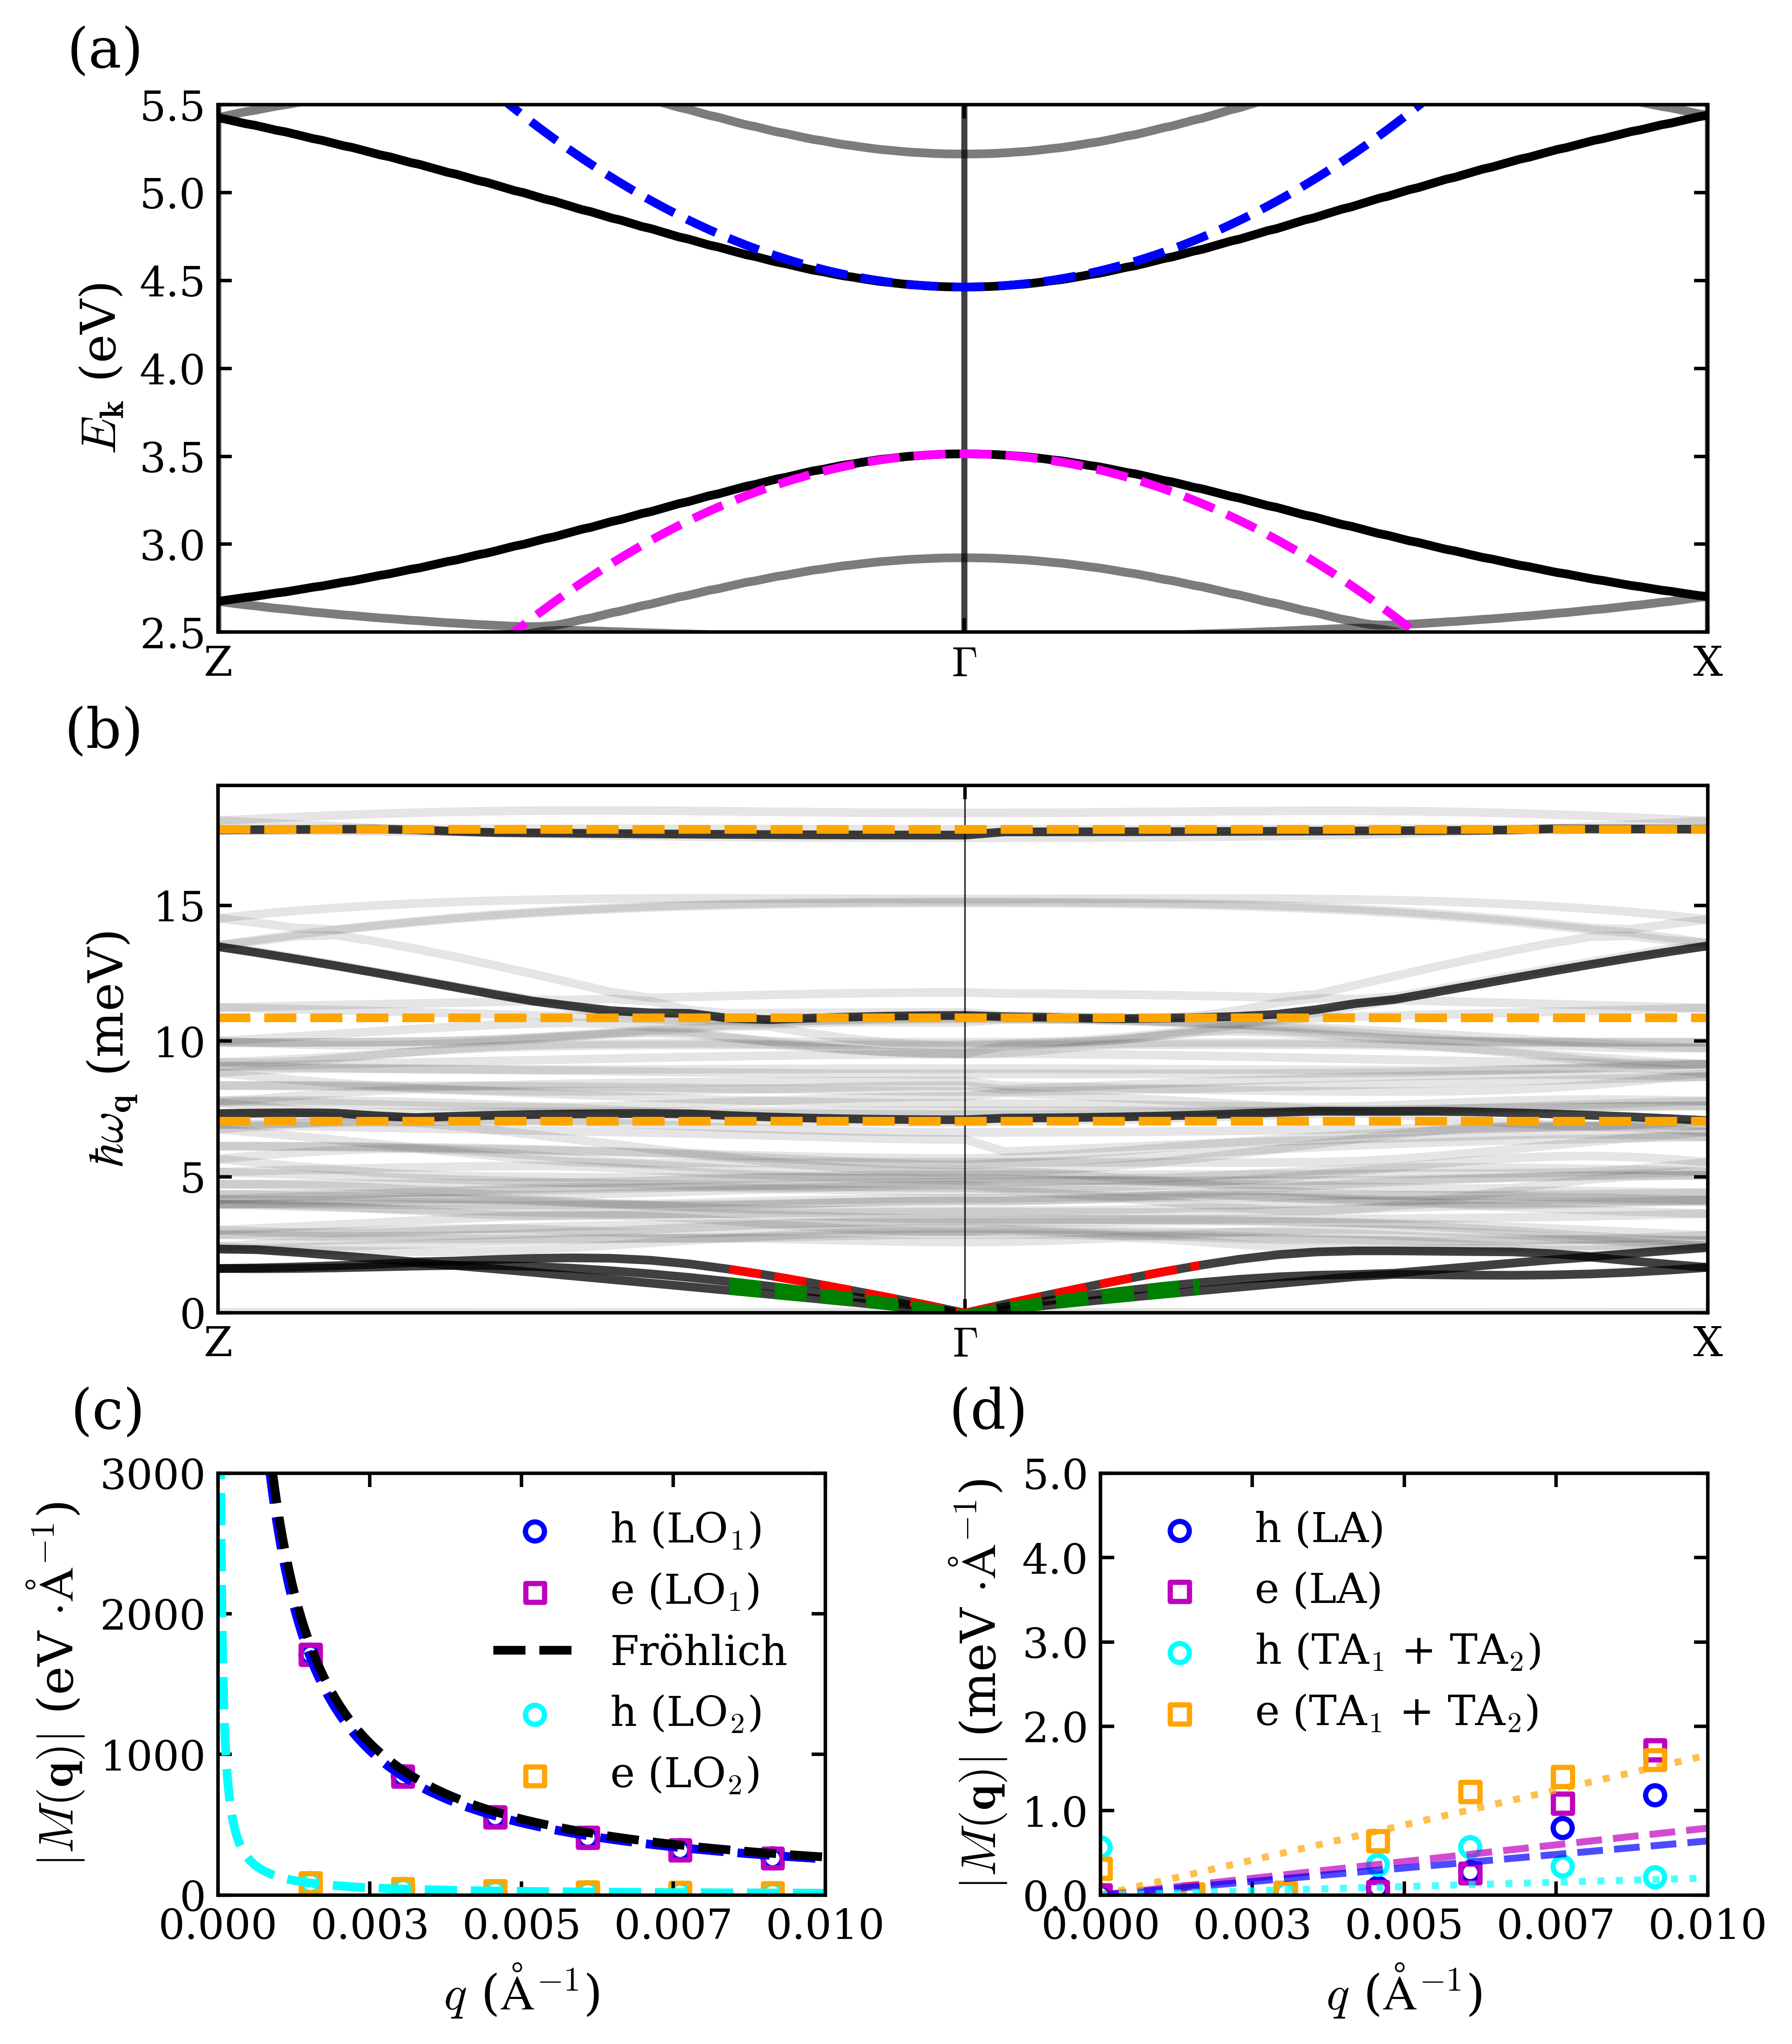

In [12]:
from pylab import *
from numpy import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numba
from scipy.optimize import curve_fit
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import matplotlib as mpl
from matplotlib import rcParams


scale = 1.0

main_text_size = 14
tick_label_size = 12
legend_size = 12
lab_size = 16

# Set publication quality parameters with scaled fonts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif', 'Computer Modern Roman', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['font.sans-serif'] = ['CMU Sans Serif', 'Computer Modern Sans Serif', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rcParams['font.size'] = 12 * scale
plt.rcParams['axes.labelsize'] = 12 * scale
plt.rcParams['xtick.labelsize'] = 10 * scale
plt.rcParams['ytick.labelsize'] = 10 * scale
plt.rcParams['legend.fontsize'] = 11 * scale
plt.rcParams['axes.linewidth'] = 1.5 * scale
plt.rcParams['xtick.major.width'] = 1.5 * scale
plt.rcParams['ytick.major.width'] = 1.5 * scale
plt.rcParams['xtick.major.size'] = 6 * scale
plt.rcParams['ytick.major.size'] = 6 * scale
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.formatter.use_mathtext'] = True

plt.rcParams['font.size'] = main_text_size
plt.rcParams['axes.labelsize'] = main_text_size
plt.rcParams['xtick.labelsize'] = tick_label_size
plt.rcParams['ytick.labelsize'] = tick_label_size
plt.rcParams['legend.fontsize'] = legend_size
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

fig_width_inches = 7.05
aspect_ratio = 16/14
fig_height_inches = fig_width_inches * aspect_ratio


fig = plt.figure(figsize=(fig_width_inches, fig_height_inches), constrained_layout=True)
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.8])

# Panel (a) - Electronic band structure (Row 1, spans both columns)
ax1 = fig.add_subplot(gs[0, :])
V = 130.1037
Nc = 1
w = 0.0030977429327
pek = 1/3.3 - 1/11.3

data = np.loadtxt("cspbbr3/cspbbr3_bands.dat.gnu")

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

# Find the CBM and VBM band indices at Gamma point
gamma_idx = np.argmin(np.abs(k - 0.1095))
E_CBM = 4.463
E_VBM = 3.514

# Find which bands are closest to CBM and VBM energies at Gamma
cbm_band_idx = np.argmin(np.abs(bands[:, gamma_idx] - E_CBM))
vbm_band_idx = np.argmin(np.abs(bands[:, gamma_idx] - E_VBM))

# Plot bands with different opacity
for band in range(len(bands)):
    if band == cbm_band_idx or band == vbm_band_idx:
        ax1.plot(k, bands[band, :], linewidth=2.5*scale, alpha=1.0, color='black')
    else:
        ax1.plot(k, bands[band, :], linewidth=2.5*scale, alpha=0.3, color='black')

ax1.set_xlim(min(k), max(k))

ax1.axvline(0.0773, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(0.1095, linewidth=1.75*scale, color='k', alpha=0.75)
ax1.axvline(0.1416, linewidth=1.75*scale, color='k', alpha=0.75)

ax1.set_xticks([0.0773, 0.1095, 0.1416])
ax1.set_xticklabels(['Z', r'$\Gamma$', 'X'])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.set_ylabel(r"$E_{\mathbf{k}}$ (eV)")  
ax1.set_ylim([2.5, 5.5])

# CsPbBr3 parameters
m_e = 0.20
m_h = 0.20
E_CBM = 4.463
E_VBM = 3.514
gamma_x = 0.1095

# CsPbBr3 lattice parameters
a_angstrom = 8.25
b_angstrom = 11.753
c_angstrom = 8.204

a_bohr = a_angstrom * 1.8897259886
b_bohr = b_angstrom * 1.8897259886
c_bohr = c_angstrom * 1.8897259886

# High symmetry point positions on the path
k_at_Z = 0.0773
k_at_X = 0.1416

# Path distances in QE plot
path_Z_to_Gamma = gamma_x - k_at_Z
path_Gamma_to_X = k_at_X - gamma_x

Z_to_Gamma_reciprocal = np.pi/c_bohr
Gamma_to_X_reciprocal = np.pi/a_bohr

# Scaling factors to convert path distance to real k-space
scale_left = Z_to_Gamma_reciprocal / path_Z_to_Gamma
scale_right = Gamma_to_X_reciprocal / path_Gamma_to_X

hartree_to_eV = 27.2114

# For k < gamma_x (Z side)
k_left = k[(k >= k_at_Z) & (k <= gamma_x)]
k_real_left = scale_left * np.abs(k_left - gamma_x)
E_CB_left = E_CBM + (hartree_to_eV / (2 * m_e)) * k_real_left**2
E_VB_left = E_VBM - (hartree_to_eV / (2 * m_h)) * k_real_left**2

# For k > gamma_x (X side)
k_right = k[(k >= gamma_x) & (k <= k_at_X)]
k_real_right = scale_right * np.abs(k_right - gamma_x)
E_CB_right = E_CBM + (hartree_to_eV / (2 * m_e)) * k_real_right**2
E_VB_right = E_VBM - (hartree_to_eV / (2 * m_h)) * k_real_right**2

# Combine for plotting
k_combined = np.concatenate([k_left, k_right[1:]])
E_CB_combined = np.concatenate([E_CB_left, E_CB_right[1:]])
E_VB_combined = np.concatenate([E_VB_left, E_VB_right[1:]])

ax1.plot(k_combined, E_CB_combined, linestyle='dashed', linewidth=2.5*scale, color='blue')
ax1.plot(k_combined, E_VB_combined, linestyle='dashed', linewidth=2.5*scale, color='magenta')

ax1.set_xlim([0.0773, 0.1416])

# Add label (a) outside the plot
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (b) - Phonon dispersion (Row 2, spans both columns)
ax2 = fig.add_subplot(gs[1, :])
data = np.loadtxt("cspbbr3/cspbbr3.freq.gp")

nbands = data.shape[1]

# Emphasized phonon bands for CsPbBr3
emphasized_bands = [1, 2, 3, 32, 51, 58]

# Plot phonon bands with different opacity
for band in range(nbands):
    if band in emphasized_bands:
        ax2.plot(data[:, 0], data[:, band]*0.00012*1000, linewidth=2.5*scale, alpha=0.75, color='black')
    else:
        ax2.plot(data[:, 0], data[:, band]*0.00012*1000, linewidth=2.5*scale, alpha=0.1, color='black')

# High symmetry k-points
ax2.axvline(x=data[57, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[76, 0], linewidth=0.5*scale, color='k', alpha=0.75)
ax2.axvline(x=data[95, 0], linewidth=0.5*scale, color='k', alpha=0.75)

ax2.set_xticks([data[57, 0], data[76, 0], data[95, 0]])
ax2.set_xticklabels(['Z', r'$\Gamma$', 'X'])
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax2.set_ylabel(r"$\hbar \omega_{\mathbf{q}}$ (meV)")
ax2.set_xlim(data[57, 0], data[95, 0])
ax2.set_ylim(0, )
ax2.axhline(data[0, 58]*0.00012*1000, color='orange', linestyle='dashed', linewidth=2.5*scale)
ax2.axhline(data[0, 51]*0.00012*1000, color='orange', linestyle='dashed', linewidth=2.5*scale)
ax2.axhline(data[0, 32]*0.00012*1000, color='orange', linestyle='dashed', linewidth=2.5*scale)

# LA mode in RED (dashed)
ax2.plot(data[70:77, 0], data[70:77, 3]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='red')
ax2.plot(data[76:83, 0], data[76:83, 3]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='red')

# TA1 mode in GREEN (dashed)
ax2.plot(data[70:77, 0], data[70:77, 1]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')
ax2.plot(data[76:83, 0], data[76:83, 1]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')

# TA2 mode in GREEN (dashed)
ax2.plot(data[70:77, 0], data[70:77, 2]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')
ax2.plot(data[76:83, 0], data[76:83, 2]*0.00012*1000, linestyle='dashed', linewidth=2.5*scale, color='green')

# Add label (b) outside the plot
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (c) - LO MODE (Row 3, left column)
ax3 = fig.add_subplot(gs[2, 0])
qx = np.loadtxt("cspbbr3/qpath.txt")[:, 0]
qy = np.loadtxt("cspbbr3/qpath.txt")[:, 1]
qz = np.loadtxt("cspbbr3/qpath.txt")[:, 2]

omega = np.loadtxt("cspbbr3/vb_58.txt")[:, 5]/27.211386245988/1000
vb_LO = np.loadtxt("cspbbr3/vb_58.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega)*5373.4583*786.53)/0.529177
cb_LO = np.loadtxt("cspbbr3/cb_58.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega)*5373.4583*786.53)/0.529177

qmag = np.zeros(len(qx))
for i in range(len(qx)):
    a, b, c = qx[i], qy[i], qz[i]
    qmag[i] = np.sqrt(a**2 + b**2 + c**2)*(2*np.pi)*0.0641/0.529177

qmag1 = np.arange(1, 602)
ax3.scatter(qmag[1:12], (vb_LO[1:12]*27.211386245988), label=r'h (LO$_1$)',
            marker='o', facecolors='none', edgecolors='blue', s=30*scale**2, linewidth=1.5*scale)
ax3.scatter(qmag[1:12], (cb_LO[1:12]*27.211386245988), label=r'e (LO$_1$)',
            marker='s', facecolors='none', edgecolors='m', s=30*scale**2, linewidth=1.5*scale)

ax3.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax3.set_xlim([0.0, 0.01])
ax3.set_ylim([0.0, 3000])
ax3.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")                           
ax3.set_ylabel(r"$|M(\mathbf{q})|$ (eV $\cdot \mathrm{\AA}^{-1}$)")   

def func(x, D):
    return (D/x)

popt, pcov = curve_fit(func, qmag[1:10], cb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(0.00001, qmag[12], 5000), func(np.linspace(0.00001, qmag[12], 5000), *popt)*27.211386245988,
         linestyle='dashed', color='m', linewidth=2.5*scale)

popt, pcov = curve_fit(func, qmag[1:10], vb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(0.00001, qmag[12], 5000), func(np.linspace(0.00001, qmag[12], 5000), *popt)*27.211386245988,
         linestyle='dashed', color='b', linewidth=2.5*scale)

V = 5373.4583
Nc = 1
w = 0.0006721085145339296
pek = 1/4.4 - 1/18.6
q_Fr = np.linspace(0.000001, qmag[13], 10000)
froh = np.sqrt((4*np.pi/(1*V))*pek*0.5*w)/0.529177 * np.sqrt(2*w*5373.4583*786.53)/0.529177
ax3.plot(q_Fr, froh/q_Fr*27.211386245988, label=r'Fröhlich', linewidth=2.5*scale, linestyle='dashed', color='black')

# Second LO mode (LO2)
omega = np.loadtxt("cspbbr3/vb_51.txt")[:, 5]/27.211386245988/1000
vb_LO = np.loadtxt("cspbbr3/vb_51.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega)*5373.4583*786.53)/0.529177
cb_LO = np.loadtxt("cspbbr3/cb_51.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega)*5373.4583*786.53)/0.529177

qmag = np.zeros(len(qx))
for i in range(len(qx)):
    a, b, c = qx[i], qy[i], qz[i]
    qmag[i] = np.sqrt(a**2 + b**2 + c**2)*(2*np.pi)*0.0641/0.529177

qmag1 = np.arange(1, 602)
ax3.scatter(qmag[1:12], (vb_LO[1:12]*27.211386245988), label=r'h (LO$_2$)',
            marker='o', facecolors='none', edgecolors='cyan', s=30*scale**2, linewidth=1.5*scale)
ax3.scatter(qmag[1:12], (cb_LO[1:12]*27.211386245988), label=r'e (LO$_2$)',
            marker='s', facecolors='none', edgecolors='orange', s=30*scale**2, linewidth=1.5*scale)

popt, pcov = curve_fit(func, qmag[1:10], cb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(0.00001, qmag[12], 5000), func(np.linspace(0.00001, qmag[12], 5000), *popt)*27.211386245988,
         linestyle='dashed', color='orange', linewidth=2.5*scale)

popt, pcov = curve_fit(func, qmag[1:10], vb_LO[1:10], p0=(1000.0))
ax3.plot(np.linspace(0.00001, qmag[12], 5000), func(np.linspace(0.00001, qmag[12], 5000), *popt)*27.211386245988,
         linestyle='dashed', color='cyan', linewidth=2.5*scale)

ax3.legend(loc='best', frameon=False)

# Add label (c) outside the plot
ax3.text(-0.12, 1.08, '(c)', transform=ax3.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# Panel (d) - Combined LA and TA MODES (Row 3, right column)
ax4 = fig.add_subplot(gs[2, 1])

# LA MODE
omega = np.loadtxt("cspbbr3/vb_LA.txt")[:, 5]/27.211386245988/1000
vb_LA = np.loadtxt("cspbbr3/vb_LA.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega)*5373.4583*786.53)/0.529177
cb_LA = np.loadtxt("cspbbr3/cb_LA.txt")[:, 6]/27.211386245988/1000*np.sqrt(2*abs(omega)*5373.4583*786.53)/0.529177

ax4.scatter(qmag[0:12], (vb_LA[0:12])*27.211386245988*1000, label=r'h (LA)',
            marker='o', facecolors='none', edgecolors='blue', s=30*scale**2, linewidth=1.5*scale)
ax4.scatter(qmag[0:12], (cb_LA[0:12])*27.211386245988*1000, label=r'e (LA)',
            marker='s', facecolors='none', edgecolors='m', s=30*scale**2, linewidth=1.5*scale)

# TA MODES
omega1 = np.loadtxt("cspbbr3/vb_TA1.txt")[:, 5]/27.211386245988/1000
omega2 = np.loadtxt("cspbbr3/vb_TA2.txt")[:, 5]/27.211386245988/1000

vb_TA = (np.loadtxt("cspbbr3/vb_TA1.txt")[:, 6])/27.211386245988/1000*np.sqrt(2*abs(omega1)*5373.4583*786.53)/0.529177
vb_TA = vb_TA + (np.loadtxt("cspbbr3/vb_TA2.txt")[:, 6])/27.211386245988/1000*np.sqrt(2*abs(omega2)*5373.4583*786.53)/0.529177
cb_TA = (np.loadtxt("cspbbr3/cb_TA1.txt")[:, 6])/27.211386245988/1000*np.sqrt(2*abs(omega1)*5373.4583*786.53)/0.529177
cb_TA = cb_TA + (np.loadtxt("cspbbr3/cb_TA2.txt")[:, 6])/27.211386245988/1000*np.sqrt(2*abs(omega2)*5373.4583*786.53)/0.529177

ax4.scatter(qmag[0:12], (vb_TA[0:12])*27.211386245988*1000, label=r'h (TA$_1$ + TA$_2$)',
            marker='o', facecolors='none', edgecolors='cyan', s=30*scale**2, linewidth=1.5*scale)
ax4.scatter(qmag[0:12], (cb_TA[0:12])*27.211386245988*1000, label=r'e (TA$_1$ + TA$_2$)',
            marker='s', facecolors='none', edgecolors='orange', s=30*scale**2, linewidth=1.5*scale)

ax4.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax4.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")                             
ax4.set_ylabel(r"$|M(\mathbf{q})|$ (meV $\cdot \mathrm{\AA}^{-1}$)")    

def func_linear(x, D):
    return D*x

# Fit LA modes
popt, pcov = curve_fit(func_linear, qmag[1:6], cb_LA[1:6], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[12], 500), func_linear(np.linspace(0, qmag[12], 500), *popt)*27.211386245988*1000,
         linestyle='dashed', color='m', linewidth=2.0*scale, alpha=0.7)

popt, pcov = curve_fit(func_linear, qmag[1:6], vb_LA[1:6], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[12], 500), func_linear(np.linspace(0, qmag[12], 500), *popt)*27.211386245988*1000,
         linestyle='dashed', color='blue', linewidth=2.0*scale, alpha=0.7)

# Fit TA modes
popt, pcov = curve_fit(func_linear, qmag[1:6], cb_TA[1:6], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[12], 500), func_linear(np.linspace(0, qmag[12], 500), *popt)*27.211386245988*1000,
         linestyle='dotted', color='orange', linewidth=2.0*scale, alpha=0.7)

popt, pcov = curve_fit(func_linear, qmag[1:10], vb_TA[1:10], p0=(1000.0))
ax4.plot(np.linspace(0, qmag[12], 500), func_linear(np.linspace(0, qmag[12], 500), *popt)*27.211386245988*1000,
         linestyle='dotted', color='cyan', linewidth=2.0*scale, alpha=0.7)

ax4.set_xlim([0, 0.010])
ax4.set_ylim([0, 5])
ax4.legend(loc='best', frameon=False, ncol=1)

# Add label (d) outside the plot
ax4.text(-0.12, 1.08, '(d)', transform=ax4.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

plt.show()
#fig.savefig('cspbbr3_figure.pdf', format='pdf', bbox_inches='tight')

This is for plotting the 0K exciton binding and polaron binding results

Alpha values:
  MgO:      α_e = 1.5921, α_h = 6.1052
  CdS:      α_e = 0.4514, α_h = 1.8473
  AgCl:     α_e = 1.8637, α_h = 3.3697
  CsPbBr3:  α_e = 2.1333, α_h = 2.1333

Calculating Feynman polaron binding energies at T=0...
  CdS: E_e = -15.43 meV, E_h = -64.40 meV
  CsPbBr$_3$: E_e = -39.54 meV, E_h = -39.54 meV
  AgCl: E_e = -38.23 meV, E_h = -70.85 meV
  MgO: E_e = -136.60 meV, E_h = -575.51 meV


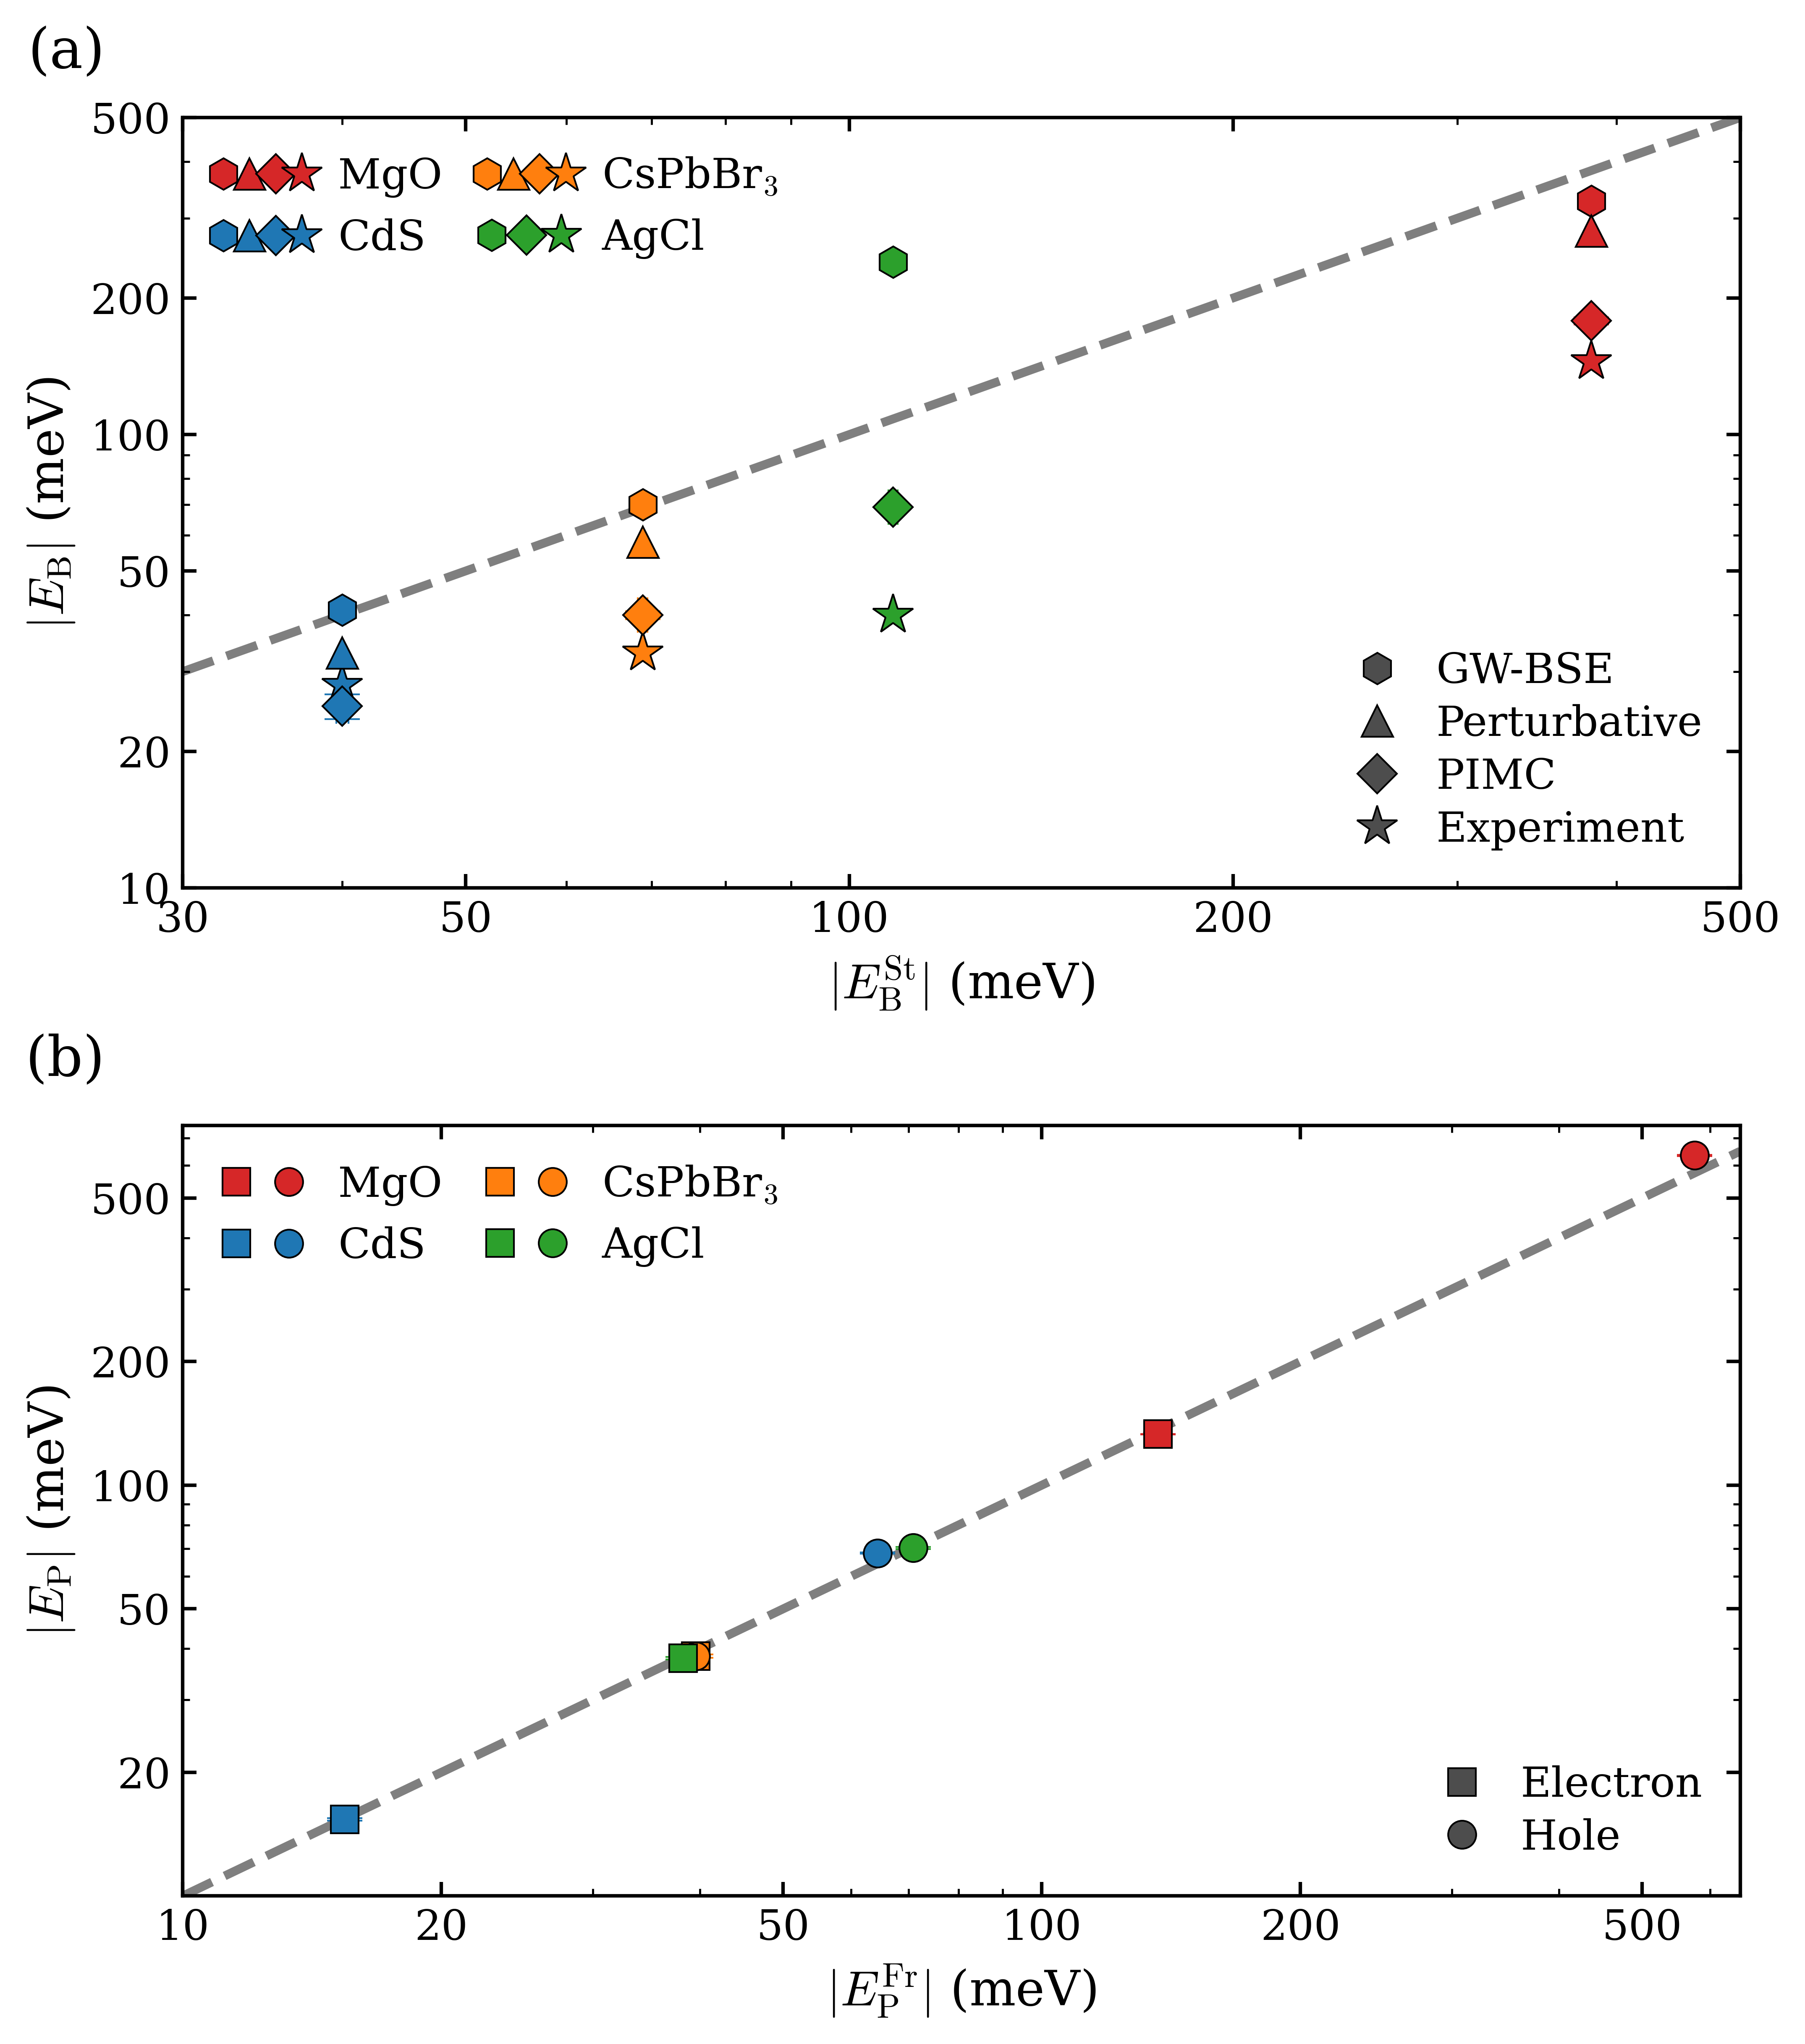

In [4]:
from pylab import *
from numpy import random
import matplotlib.pyplot as plt
import numba
from scipy.optimize import curve_fit, minimize
from scipy.integrate import quad
from matplotlib.ticker import MaxNLocator, FormatStrFormatter, LogLocator, NullFormatter
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.gridspec as gridspec
from matplotlib.legend_handler import HandlerErrorbar
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# =============================================================================
# Free Energy for Feynman's Polaron Bound
# =============================================================================

def intB(x, v, w, alpha, beta):
    """B integrand from Hellwarth - with overflow protection"""
    if beta > 50:
        thermal = np.exp(-x)
    else:
        thermal = (np.exp(-x) + np.exp(x - beta)) / (1 - np.exp(-beta))
    
    pref = alpha * v / np.sqrt(np.pi)
    
    Y = (1 / (1 - np.exp(-v * beta))) * (1 + np.exp(-v * beta) - np.exp(-v * x) - np.exp(v * (x - beta)))
    D = (w**2) * x * (1 - x / beta) + Y * (v**2 - w**2) / v
    
    if D <= 1e-15:
        return 0.0
    
    return pref * thermal / np.sqrt(D)


def free_energy(v, w, alpha, beta):
    """Free energy F = -(A + B + C) following Hellwarth convention"""
    if v <= w or v <= 0 or w <= 0:
        return 1e10
    
    if 0.5 * beta * v > 50:
        log_sinh_ratio = 0.5 * beta * (v - w)
    else:
        log_sinh_ratio = np.log(np.sinh(0.5 * v * beta) / np.sinh(0.5 * w * beta))
    
    A = (3 / beta) * (np.log(v / w) - 0.5 * np.log(2 * np.pi * beta) - log_sinh_ratio)
    
    if 0.5 * v * beta > 50:
        coth_term = 1.0
    else:
        coth_term = 1 / np.tanh(0.5 * v * beta)
    
    C = (0.75 * (v**2 - w**2) / v) * (coth_term - 2 / (v * beta))
    
    eps = 1e-10
    upper = 0.5 * beta - eps
    I, _ = quad(intB, eps, upper, args=(v, w, alpha, beta), limit=100)
    B = I
    
    return -A - B - C


def opt(par, alpha, beta):
    """Objective function for optimization"""
    v, w = par[0], par[1]
    return free_energy(v, w, alpha, beta)


def internal_energy_numerical(v, w, alpha, beta, delta=0.002):
    """Internal energy via E = ∂(βF)/∂β"""
    db = beta * delta
    F_plus = free_energy(v, w, alpha, beta + db)
    F_minus = free_energy(v, w, alpha, beta - db)
    return ((beta + db) * F_plus - (beta - db) * F_minus) / (2 * db)


def binding_energy(v, w, alpha, beta):
    """Binding (self) energy: E_s = E - E_free"""
    E = internal_energy_numerical(v, w, alpha, beta)
    E_free = 1.5 / beta
    return E - E_free


def optimize_polaron_fast(alpha, beta, v0=3.0, w0=2.5):
    """Fast optimization using warm start"""
    constraints = {'type': 'ineq', 'fun': lambda x: x[0] - x[1] - 1e-6}
    bounds = [(0.01, 50), (0.01, 50)]
    
    try:
        out = minimize(opt, [v0, w0], args=(alpha, beta),
                       method='SLSQP', bounds=bounds,
                       constraints=constraints, tol=1e-8)
        if out.success and out.fun < 1e9:
            return out
    except:
        pass
    
    fallback_inits = [(3.0, 2.0), (5.0, 3.0), (2.0, 1.0), (4.0, 2.5), (6.0, 4.0)]
    for v_init, w_init in fallback_inits:
        try:
            out = minimize(opt, [v_init, w_init], args=(alpha, beta),
                           method='SLSQP', bounds=bounds,
                           constraints=constraints, tol=1e-8)
            if out.success and out.fun < 1e9:
                return out
        except:
            pass
    
    class FallbackResult:
        def __init__(self, v, w, alpha, beta):
            self.x = np.array([v, w])
            self.fun = free_energy(v, w, alpha, beta)
            self.success = False
    return FallbackResult(v0, w0, alpha, beta)


# =============================================================================
# Plot parameters
# =============================================================================

scale = 1.0

main_text_size = 14
tick_label_size = 12
legend_size = 12
lab_size = 16

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif', 'Computer Modern Roman', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['font.sans-serif'] = ['CMU Sans Serif', 'Computer Modern Sans Serif', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rcParams['font.size'] = main_text_size
plt.rcParams['axes.labelsize'] = main_text_size
plt.rcParams['xtick.labelsize'] = tick_label_size
plt.rcParams['ytick.labelsize'] = tick_label_size
plt.rcParams['legend.fontsize'] = legend_size
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.formatter.use_mathtext'] = True

# =============================================================================
# Data
# =============================================================================

# Exciton binding data (order is CdS, CsPbBr3, AgCl, MgO)
wan = -np.array([-40.022924218982034,-68.85528339872535,-108.26076731366383,-382.2])
gw = -np.array([-41,-70,-240,-327])
wan_err = np.array([0.45,0.60,0.90,1.1])
# --- UPDATED Exciton Binding Energies (all four materials) ---
mod = -np.array([-25.157, -39.948, -69.128, -178.165])
mod_err = np.array([1.59, 0.772, 0.87, 3.28])

# Antonios data (CdS, CsPbBr3, MgO — no AgCl)
ant = np.array([33, 58, 281])

# Updated experimental data
exp = -np.array([-28,-33,-40,-145])

# BSE data (same x-values as wan, y-values from gw)
bse = gw

# --- UPDATED Polaron Binding Energies (all four materials) ---
# Polaron data (0K values, including LO + Ac contributions)
agcl_e_p = np.array([-37.8946])
agcl_e_err_p = np.array([0.278])
cds_e_p = np.array([-15.3616])
cds_e_err_p = np.array([0.0964])
mgo_e_p = np.array([-133.03])
mgo_e_err_p = np.array([0.197])
perov_e_p = np.array([-38.349])
perov_e_err_p = np.array([0.360])

agcl_h_p = np.array([-70.3458])
agcl_h_err_p = np.array([0.4518])
cds_h_p = np.array([-68.3387])
cds_h_err_p = np.array([0.3019])
mgo_h_p = np.array([-634.565])
mgo_h_err_p = np.array([2.488])
# CsPbBr3: m_e = m_h and negligible deformation potentials => hole == electron (physical)
perov_h_p = np.array([-38.349])
perov_h_err_p = np.array([0.360])
# ---------------------------------------------

# =============================================================================
# Material Parameters and Feynman calculations
# =============================================================================

Ha_to_meV = 27.2114 * 1000

# MgO
ep_mgo, ep_st_mgo = 3.3, 11.3
pek_mgo = 1/ep_mgo - 1/ep_st_mgo
wlo_mgo_meV = 84
omega_mgo = wlo_mgo_meV / Ha_to_meV
m_e_mgo, m_h_mgo = 0.34, 5.0
alpha_e_mgo = pek_mgo * np.sqrt(0.5 * m_e_mgo / omega_mgo)
alpha_h_mgo = pek_mgo * np.sqrt(0.5 * m_h_mgo / omega_mgo)

# CdS
ep_cds, ep_st_cds = 6.2, 10.4
pek_cds = 1/ep_cds - 1/ep_st_cds
wlo_cds_meV = 34
omega_cds = wlo_cds_meV / Ha_to_meV
m_e_cds, m_h_cds = 0.12, 2.01
alpha_e_cds = pek_cds * np.sqrt(0.5 * m_e_cds / omega_cds)
alpha_h_cds = pek_cds * np.sqrt(0.5 * m_h_cds / omega_cds)

# AgCl
ep_agcl, ep_st_agcl = 4.91, 15.74
pek_agcl = 1/ep_agcl - 1/ep_st_agcl
wlo_agcl_meV = 20
omega_agcl = wlo_agcl_meV / Ha_to_meV
m_e_agcl, m_h_agcl = 0.26, 0.85
alpha_e_agcl = pek_agcl * np.sqrt(0.5 * m_e_agcl / omega_agcl)
alpha_h_agcl = pek_agcl * np.sqrt(0.5 * m_h_agcl / omega_agcl)

# CsPbBr3
ep_perov, ep_st_perov = 4.4, 18.6
pek_perov = 1/ep_perov - 1/ep_st_perov
wlo_perov_meV = 18
omega_perov = wlo_perov_meV / Ha_to_meV
m_e_perov, m_h_perov = 0.20, 0.20
alpha_e_perov = pek_perov * np.sqrt(0.5 * m_e_perov / omega_perov)
alpha_h_perov = pek_perov * np.sqrt(0.5 * m_h_perov / omega_perov)

print("Alpha values:")
print(f"  MgO:      α_e = {alpha_e_mgo:.4f}, α_h = {alpha_h_mgo:.4f}")
print(f"  CdS:      α_e = {alpha_e_cds:.4f}, α_h = {alpha_h_cds:.4f}")
print(f"  AgCl:     α_e = {alpha_e_agcl:.4f}, α_h = {alpha_h_agcl:.4f}")
print(f"  CsPbBr3:  α_e = {alpha_e_perov:.4f}, α_h = {alpha_h_perov:.4f}")

beta_0K = 1000

print("\nCalculating Feynman polaron binding energies at T=0...")

materials_data = {
    'CdS': {'alpha_e': alpha_e_cds, 'alpha_h': alpha_h_cds, 'omega': omega_cds, 'wlo_meV': wlo_cds_meV},
    'CsPbBr$_3$': {'alpha_e': alpha_e_perov, 'alpha_h': alpha_h_perov, 'omega': omega_perov, 'wlo_meV': wlo_perov_meV},
    'AgCl': {'alpha_e': alpha_e_agcl, 'alpha_h': alpha_h_agcl, 'omega': omega_agcl, 'wlo_meV': wlo_agcl_meV},
    'MgO': {'alpha_e': alpha_e_mgo, 'alpha_h': alpha_h_mgo, 'omega': omega_mgo, 'wlo_meV': wlo_mgo_meV}
}

feynman_e = {}
feynman_h = {}

for mat, data in materials_data.items():
    result_e = optimize_polaron_fast(data['alpha_e'], beta_0K)
    v_e, w_e = result_e.x
    E_bind_e = binding_energy(v_e, w_e, data['alpha_e'], beta_0K)
    feynman_e[mat] = E_bind_e * data['wlo_meV']
    
    result_h = optimize_polaron_fast(data['alpha_h'], beta_0K)
    v_h, w_h = result_h.x
    E_bind_h = binding_energy(v_h, w_h, data['alpha_h'], beta_0K)
    feynman_h[mat] = E_bind_h * data['wlo_meV']
    
    print(f"  {mat}: E_e = {feynman_e[mat]:.2f} meV, E_h = {feynman_h[mat]:.2f} meV")

# Dictionaries for plotting PIMC data
pimc_e_0K = {
    'CdS': -cds_e_p[0],
    'CsPbBr$_3$': -perov_e_p[0],
    'AgCl': -agcl_e_p[0],
    'MgO': -mgo_e_p[0]
}
pimc_e_err_0K = {
    'CdS': cds_e_err_p[0],
    'CsPbBr$_3$': perov_e_err_p[0],
    'AgCl': agcl_e_err_p[0],
    'MgO': mgo_e_err_p[0]
}

pimc_h_0K = {
    'CdS': -cds_h_p[0],
    'CsPbBr$_3$': -perov_h_p[0],
    'AgCl': -agcl_h_p[0],
    'MgO': -mgo_h_p[0]
}
pimc_h_err_0K = {
    'CdS': cds_h_err_p[0],
    'CsPbBr$_3$': perov_h_err_p[0],
    'AgCl': agcl_h_err_p[0],
    'MgO': mgo_h_err_p[0]
}

feynman_e_abs = {mat: -val for mat, val in feynman_e.items()}
feynman_h_abs = {mat: -val for mat, val in feynman_h.items()}


materials = ['CdS', 'CsPbBr$_3$', 'AgCl', 'MgO']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig_width_inches = 7.05

fig = plt.figure(figsize=(fig_width_inches, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Neutral gray used for the method (shape) legends, so shape reads independent of color
method_gray = '#4d4d4d'

# =============================================================================
# Panel (a): Exciton binding energy (log-log)
# =============================================================================

ax1_xlim = (30, 500)
ax1_ylim = (10, 500)
ax1.plot(ax1_xlim, ax1_xlim, 'k--', alpha=0.5, linewidth=2.5*scale)

for i, (mat, color) in enumerate(zip(materials, colors)):
    ax1.errorbar(wan[i], mod[i], xerr=wan_err[i], yerr=mod_err[i],
                 fmt='D', markersize=8*scale, capsize=5*scale, capthick=1.5*scale,
                 color=color, markeredgecolor='black',
                 markeredgewidth=0.5, elinewidth=1.5*scale)
    ax1.plot(wan[i], bse[i], 'h', markersize=9*scale,
             color=color, markeredgecolor='black', markeredgewidth=0.5)

# Plot all four experimental values as stars
for i in range(len(materials)):
    ax1.plot(wan[i], exp[i], '*', markersize=12*scale,
             color=colors[i], markeredgecolor='black',
             markeredgewidth=0.5)

# Plot Antonios data as triangles (CdS, CsPbBr3, MgO — no AgCl)
ant_wan_indices = [0, 1, 3]
for j, idx in enumerate(ant_wan_indices):
    ax1.plot(wan[idx], ant[j], '^', markersize=9*scale,
             color=colors[idx], markeredgecolor='black',
             markeredgewidth=0.5)

ax1.set_xlabel(r'$|E_{\mathrm{B}}^{\mathrm{St}}|$ (meV)')
ax1.set_ylabel(r'$|E_{\mathrm{B}}|$ (meV)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(ax1_xlim)
ax1.set_ylim(ax1_ylim)

ax1.set_xticks([30, 50, 100, 200, 500])
ax1.get_xaxis().set_major_formatter(FormatStrFormatter('%d'))
ax1.set_yticks([10, 20, 50, 100, 200, 500])
ax1.get_yaxis().set_major_formatter(FormatStrFormatter('%d'))

# ---- Legend 1 (material -> color), upper left ----
legend_order = ['MgO', 'CdS', r'CsPbBr$_3$', 'AgCl']
legend_colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c']
legend_has_triangle = [True, True, True, False]

legend_handles_a = []
for color, has_tri in zip(legend_colors, legend_has_triangle):
    diamond = Line2D([0], [0], marker='D', color='w', markerfacecolor=color,
                     markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5)
    hexagon = Line2D([0], [0], marker='h', color='w', markerfacecolor=color,
                     markersize=9*scale, markeredgecolor='black', markeredgewidth=0.5)
    star = Line2D([0], [0], marker='*', color='w', markerfacecolor=color,
                  markersize=12*scale, markeredgecolor='black', markeredgewidth=0.5)
    if has_tri:
        triangle = Line2D([0], [0], marker='^', color='w', markerfacecolor=color,
                          markersize=9*scale, markeredgecolor='black', markeredgewidth=0.5)
        # Order: GW-BSE (hexagon), Perturbative (triangle), PIMC (diamond), Experiment (star)
        legend_handles_a.append((hexagon, triangle, diamond, star))
    else:
        # AgCl has no Perturbative point: GW-BSE (hexagon), PIMC (diamond), Experiment (star)
        legend_handles_a.append((hexagon, diamond, star))

leg1a = ax1.legend(legend_handles_a, legend_order, loc='upper left', frameon=False,
                   fancybox=False, ncol=2, columnspacing=1,
                   handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)})
ax1.add_artist(leg1a)  # keep this legend when the second is added

# ---- Legend 2 (shape -> method), lower right, neutral gray ----
# Order: GW-BSE (hexagon), Perturbative (triangle), PIMC (diamond), Experiment (star)
method_handles_a = [
    Line2D([0], [0], marker='h', color='w', markerfacecolor=method_gray,
           markersize=9*scale, markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='^', color='w', markerfacecolor=method_gray,
           markersize=9*scale, markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=method_gray,
           markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='*', color='w', markerfacecolor=method_gray,
           markersize=12*scale, markeredgecolor='black', markeredgewidth=0.5),
]
method_labels_a = ['GW-BSE', 'Perturbative', 'PIMC', 'Experiment']
ax1.legend(method_handles_a, method_labels_a, loc='lower right', frameon=False,
           fancybox=False, ncol=1, handletextpad=0.4, labelspacing=0.3)

ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

# =============================================================================
# Panel (b): Polaron binding energy (log-log)
# =============================================================================

ax2_xlim = (10, 650)
ax2_ylim = (10, 750)
ax2.plot(ax2_xlim, ax2_xlim, 'k--', alpha=0.5, linewidth=2.5*scale)

for i, (mat, color) in enumerate(zip(materials, colors)):
    # Electrons are squares ('s')
    ax2.errorbar(feynman_e_abs[mat], pimc_e_0K[mat], yerr=pimc_e_err_0K[mat],
                 fmt='s', markersize=8*scale, capsize=5*scale, capthick=1.5*scale,
                 color=color, markeredgecolor='black', markeredgewidth=0.5,
                 elinewidth=1.5*scale)
    # Holes are circles ('o')
    ax2.errorbar(feynman_h_abs[mat], pimc_h_0K[mat], yerr=pimc_h_err_0K[mat],
                 fmt='o', markersize=8*scale, capsize=5*scale, capthick=1.5*scale,
                 color=color, markeredgecolor='black', markeredgewidth=0.5,
                 elinewidth=1.5*scale)

ax2.set_xlabel(r'$|E_{\mathrm{P}}^{\mathrm{Fr}}|$ (meV)')
ax2.set_ylabel(r'$|E_{\mathrm{P}}|$ (meV)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(ax2_xlim)
ax2.set_ylim(ax2_ylim)

ax2.set_xticks([10, 20, 50, 100, 200, 500])
ax2.get_xaxis().set_major_formatter(FormatStrFormatter('%d'))
ax2.set_yticks([20, 50, 100, 200, 500])
ax2.get_yaxis().set_major_formatter(FormatStrFormatter('%d'))

# ---- Legend 1 (material -> color), upper left ----
legend_handles_b = []
for color in legend_colors:
    square = Line2D([0], [0], marker='s', color='w', markerfacecolor=color,
                    markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5)
    circle = Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                    markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5)
    legend_handles_b.append((square, circle))

leg1b = ax2.legend(legend_handles_b, legend_order, loc='upper left', frameon=False,
                   fancybox=False, ncol=2, columnspacing=1,
                   handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)})
ax2.add_artist(leg1b)

# ---- Legend 2 (shape -> carrier), lower right, neutral gray ----
method_handles_b = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=method_gray,
           markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=method_gray,
           markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5),
]
method_labels_b = ['Electron', 'Hole']
ax2.legend(method_handles_b, method_labels_b, loc='lower right', frameon=False,
           fancybox=False, ncol=1, handletextpad=0.4, labelspacing=0.3)

ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes, fontsize=lab_size,
         va='bottom', ha='right')

plt.show()

# To save the figure, uncomment the line below
# fig.savefig('polaron_exciton_comparison_final_updated.pdf', format='pdf', bbox_inches='tight')

This is for plotting the temperature-dependent exciton binding and phonon screening

FITTING RESULTS - EXCITON BINDING ENERGY

CdS:
----------------------------------------
  Screening: 1/(1 + A·n_BE): A = 11.851 ± 3.747, χ² = 2.228

AgCl:
----------------------------------------
  Screening: 1/(1 + A·n_BE): A = 0.724 ± 0.116, χ² = 1.538

CsPbBr3:
----------------------------------------
  Screening: 1/(1 + A·n_BE): A = 3.865 ± 0.846, χ² = 2.374

FITTING RESULTS - I_ph (I_LO + I_Ac)

CdS:
----------------------------------------
  Screening: 1/(1 + A·n_BE): A = 16.348 ± 2.103, χ² = 12.574

AgCl:
----------------------------------------
  Screening: 1/(1 + A·n_BE): A = 1.058 ± 0.139, χ² = 3.205

CsPbBr3:
----------------------------------------
  Screening: 1/(1 + A·n_BE): A = 3.964 ± 0.656, χ² = 0.322


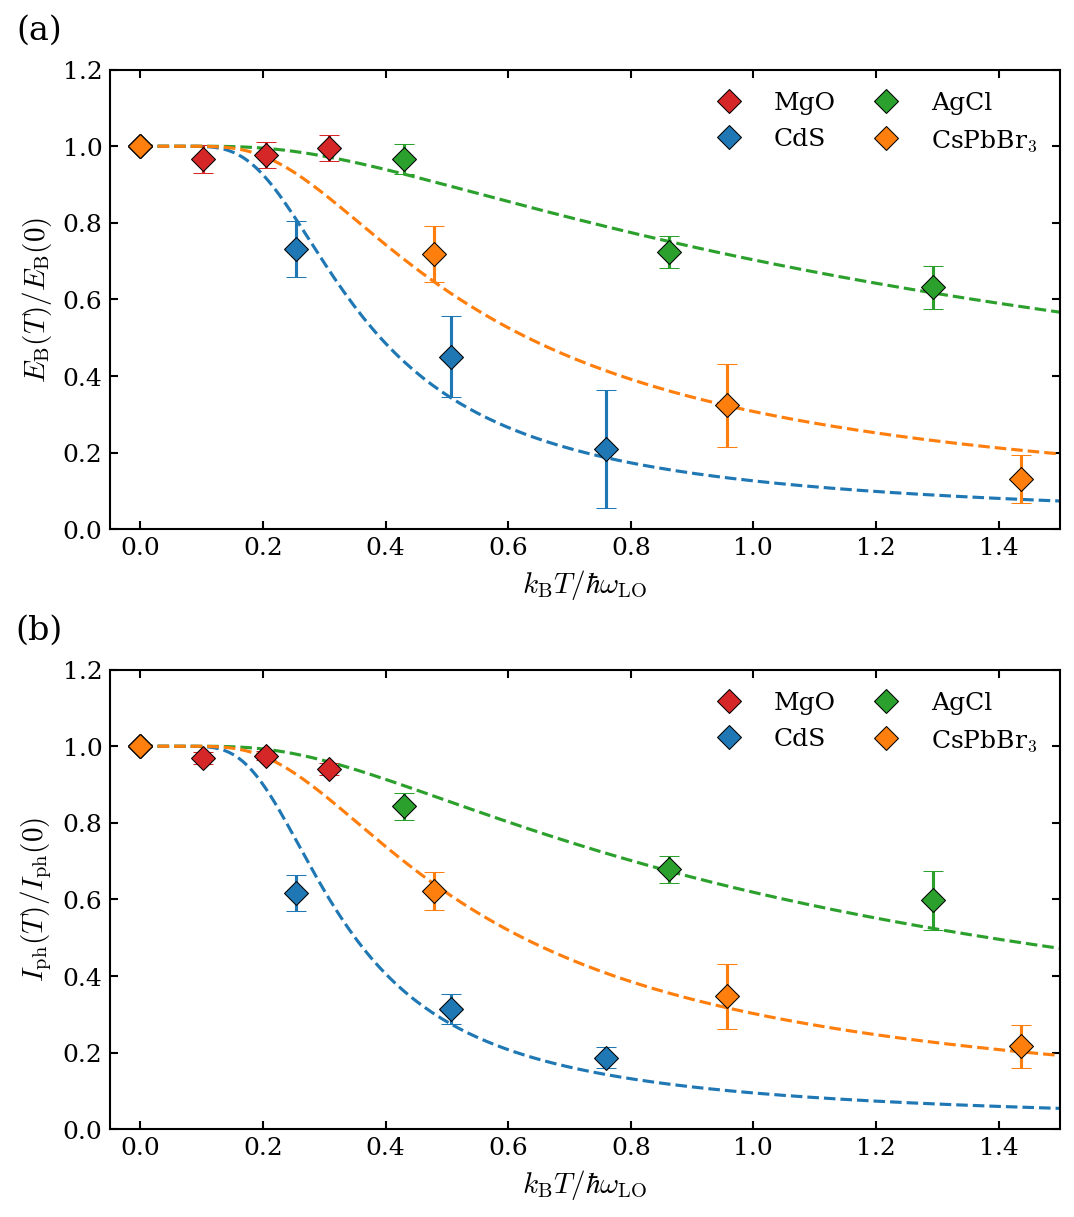

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# =============================================================================
# Plot parameters
# =============================================================================

scale = 1.0

main_text_size = 14
tick_label_size = 12
legend_size = 12
lab_size = 16

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif', 'Computer Modern Roman', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['font.sans-serif'] = ['CMU Sans Serif', 'Computer Modern Sans Serif', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rcParams['font.size'] = main_text_size
plt.rcParams['axes.labelsize'] = main_text_size
plt.rcParams['xtick.labelsize'] = tick_label_size
plt.rcParams['ytick.labelsize'] = tick_label_size
plt.rcParams['legend.fontsize'] = legend_size
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.formatter.use_mathtext'] = True

# =============================================================================
# Data
# =============================================================================

k_B = 0.08617333262  # meV/K
T_data = np.array([0, 100, 200, 300]) # Define temperature data points

# LO phonon energies
wlo_mgo = 84
wlo_cds = 34
wlo_agcl = 20
wlo_perov = 18

# =============================================================================
# Fitting functions
# =============================================================================

def n_BE(x):
    """Bose-Einstein occupation for x = kT/hw"""
    with np.errstate(divide='ignore', over='ignore'):
        result = np.where(x > 0.001, 1.0 / (np.exp(1.0/x) - 1), 0.0)
    return result

def model_screening(x, A):
    return 1.0 / (1 + A * n_BE(x))

# =============================================================================
# CsPbBr3
# =============================================================================
En = np.array([-116.6467516841472,-97.20842402822419,-91.67648405707422,-96.60131365720076])
err = np.array([0.5795267683104088,2.836921436485406,4.256010250144543,2.3211712000472557])
e_LO = np.array([-38.348988662266215,-34.252126569246144,-39.3340164439256,-45.627255226381436])
e_err_LO = np.array([0.3604757083874139,0.1717232309754889,0.5194474479761417,0.6359064832754373])
e_Ac = np.array([-0.0004754087534413145,-0.015207108304520805,-0.02992558561803925,-0.030610163322611666])
e_err_Ac = np.array([2.522207336330345e-07,4.144744434829106e-05,0.0003646060013866792, 0.0003293288553525516])
h_LO = np.array([-38.348988662266215,-34.252126569246144,-39.3340164439256,-45.627255226381436])
h_err_LO = np.array([0.3604757083874139,0.1717232309754889,0.5194474479761417,0.6359064832754373])
h_Ac = np.array([2.549881192875088e-06,-0.008030611021924153,-0.016261234688667445,-0.023625430043545066])
h_err_Ac = np.array([0.0029268805801306677,8.824299628528025e-05,2.0338089767081535e-05,0.00018786381086040432])
perov_Eb = (e_LO + e_Ac + h_LO + h_Ac) - En
perov_Eb_err = np.sqrt(e_err_LO**2 + e_err_Ac**2 + h_err_LO**2 + h_err_Ac**2 + err**2)

En_LO_ax3 = np.array([23.73466710023629,14.7837735195448,8.233943025183006,5.144488236806968])
err_LO_ax3 = np.array([0.19449742897014913,1.1736764961159705,1.9949096567610032,1.3130404464358687])
En_Ac_ax3 = np.array([2.4555941678432285e-07,0.00313056690669158,0.00123396739855548786,5.675579815744628e-05])
err_Ac_ax3 = np.array([1.696357738254747e-06,0.00030977055667033473,0.00036592268950170196,4.142681115950666e-05])
perov_I = En_LO_ax3 + En_Ac_ax3
perov_I_err = np.sqrt(err_LO_ax3**2 + err_Ac_ax3**2)

# =============================================================================
# AgCl
# =============================================================================
En = np.array([-177.36889376247137,-171.7004317570731,-173.5553984350938,-190.14377344669884])
err = np.array([0.7380584032192276,2.4940552100155253,2.874280533660404,3.8929457292991554])
e_LO = np.array([-37.568084605204064,-32.442331383889474,-36.11562800445104,-40.93511595277025])
e_err_LO = np.array([0.27805377343102755,0.07954198691550668,0.15113140709573225,0.15624446688713312])
e_Ac = np.array([-0.32653990490991947,-4.407141477033388,-8.431193102655131,-12.32174692050008])
e_err_Ac = np.array([0.0026223107260585857,0.016350308794373908,0.041964076117576576,0.0574102567429566])
h_LO = np.array([-69.8945087867578,-62.52060424363126,-69.01403766583202,-78.5054676988615])
h_err_LO = np.array([0.4518124942413809,0.15937162141572023,0.20646137364718217,0.35348768448770107])
h_Ac = np.array([-0.4513181506087195,-5.529328011248819,-9.956060816977638,-14.740865562577198])
h_err_Ac = np.array([0.002143258511499723,0.027306652837986424,0.050485652573132075,0.14263311454276012])
agcl_Eb = (e_LO + e_Ac + h_LO + h_Ac) - En
agcl_Eb_err = np.sqrt(e_err_LO**2 + e_err_Ac**2 + h_err_LO**2 + h_err_Ac**2 + err**2)

En_LO_ax3 = np.array([34.07838694843883,27.441997958661638,22.389225052124527,19.78822110482883])
err_LO_ax3 = np.array([0.2568639571998277,1.179329541680579,1.160901009623776,2.597884922896334])
En_Ac_ax3 = np.array([-0.0002788379417866218,1.3096843050046405,0.7437678390310262,0.5923771392920529])
err_Ac_ax3 = np.array([0.0006303862107574908,0.04043232212774995,0.06329771709554995,0.14440018549571235])
agcl_I = En_LO_ax3 + En_Ac_ax3
agcl_I_err = np.sqrt(err_LO_ax3**2 + err_Ac_ax3**2)

# =============================================================================
# CdS
# =============================================================================
En = np.array([-108.85735014707922,-130.0248581461518,-167.02690445275715,-223.71042816543363])
err = np.array([1.5540490606798278,1.3381069604486393,2.3099692256414044,2.7097792901317628])
e_LO = np.array([-14.753301339002341,-13.511136261685778,-12.902393404477174,-13.770997883394523])
e_err_LO = np.array([0.09634742312218351,0.03201080135887288,0.0673959713165491,0.06484604773833882])
e_Ac = np.array([-0.6083154348275667,-6.614474274047972,-12.299179731309072,-17.93690380365388])
e_err_Ac = np.array([0.0032502561654722856,0.048568631668314016,0.07354531345665102,0.07651239530211022])
h_LO = np.array([-63.35108743234187,-59.41266997087279,-61.51178788295572,-69.01193443335579])
h_err_LO = np.array([0.2979644553784368,0.21306124890901468,0.3050245008694505,0.5739198495593926])
h_Ac = np.array([-4.987674610391381,-32.075202387424625,-68.98558006445059,-117.69687704038597])
h_err_Ac = np.array([0.04900993826542861,0.36324878149018475,1.0733003244666648,2.6661467893308])
cds_Eb = (e_LO + e_Ac + h_LO + h_Ac) - En
cds_Eb_err = np.sqrt(e_err_LO**2 + e_err_Ac**2 + h_err_LO**2 + h_err_Ac**2 + err**2)

En_LO_ax3 = np.array([8.047241727950443,4.934651602733707,2.4775474118937466,1.4332116567053388])
err_LO_ax3 = np.array([0.2458092380307488,0.33955856883151553,0.30922348879221456,0.21999380310934244])
En_Ac_ax3 = np.array([0.000490830384175709, 0.031227857721508243, 0.05708159073467525, 0.07044702054792776])
err_Ac_ax3 = np.array([0.0019559426914867056, 0.0010617322386121196, 0.006136631031541986, 0.006200730046928963])
cds_I = En_LO_ax3 + En_Ac_ax3
cds_I_err = np.sqrt(err_LO_ax3**2 + err_Ac_ax3**2)

# =============================================================================
# MgO
# =============================================================================
En = np.array([-943.9537985559982,-969.3539340737163,-1011.655057559719,-1046.0461383766237])
err = np.array([2.174049971034311,4.141920755438957,4.167155305815522,4.499708231759069])
e_LO = np.array([-131.0551339258011,-126.34241615287789,-122.99422926057842,-117.97992711525839])
e_err_LO = np.array([0.17813585342978622,0.31059519157420584,0.18669448271277145,0.21548494105037633])
e_Ac = np.array([-0.16704692498873192,-0.2954002449515261,-0.49467158677328016,-0.6347939925157118])
e_err_Ac = np.array([0.0008698946383105665,0.002436441195104944,0.001953200006012868,0.0029684150261139164])
h_LO = np.array([-601.0471551156652,-591.6597294466585,-595.7833948895843,-596.2400270698239])
h_err_LO = np.array([2.4674409332944687,3.3154463973022485,2.594993700975146,1.4137895320569414])
h_Ac = np.array([-33.518497861728925,-78.7143635043236,-118.33670056797047,-153.85552012214794])
h_err_Ac = np.array([0.32682424452202247,1.9139250560967864,1.7218672652298241,1.0111221226371827])
mgo_Eb = (e_LO + e_Ac + h_LO + h_Ac) - En
mgo_Eb_err = np.sqrt(e_err_LO**2 + e_err_Ac**2 + h_err_LO**2 + h_err_Ac**2 + err**2)

En_LO_ax3 = np.array([98.86553431341768,95.894028566996,96.22295173936351,92.92680093376364])
err_LO_ax3 = np.array([0.8447939392227704,1.3603225142226214,0.7471443618813419,1.229348691939952])
En_Ac_ax3 = np.array([1.9064994287429362,1.8883658251638944,2.1032365101220427,1.861435502194039])
err_Ac_ax3 = np.array([0.03181287397160498,0.022126964269016978,0.0312651187158342,0.04623469243451097])
mgo_I = En_LO_ax3 + En_Ac_ax3
mgo_I_err = np.sqrt(err_LO_ax3**2 + err_Ac_ax3**2)

# =============================================================================
# Compute normalized values
# =============================================================================
def compute_normalized(T_arr, Eb, Eb_err, wlo):
    x = k_B * T_arr / wlo
    Eb_0 = Eb[0]
    Eb_0_err = Eb_err[0]
    y = Eb / Eb_0
    y_err = np.abs(y) * np.sqrt((Eb_err / Eb)**2 + (Eb_0_err / Eb_0)**2)
    y_err[0] = 0
    return x, y, y_err

# Exciton binding energy
x_mgo, y_mgo, yerr_mgo = compute_normalized(T_data, mgo_Eb, mgo_Eb_err, wlo_mgo)
x_cds, y_cds, yerr_cds = compute_normalized(T_data, cds_Eb, cds_Eb_err, wlo_cds)
x_agcl, y_agcl, yerr_agcl = compute_normalized(T_data, agcl_Eb, agcl_Eb_err, wlo_agcl)
x_perov, y_perov, yerr_perov = compute_normalized(T_data, perov_Eb, perov_Eb_err, wlo_perov)

# I_ph (total phonon: I_LO + I_Ac)
x_mgo_I, y_mgo_I, yerr_mgo_I = compute_normalized(T_data, mgo_I, mgo_I_err, wlo_mgo)
x_cds_I, y_cds_I, yerr_cds_I = compute_normalized(T_data, cds_I, cds_I_err, wlo_cds)
x_agcl_I, y_agcl_I, yerr_agcl_I = compute_normalized(T_data, agcl_I, agcl_I_err, wlo_agcl)
x_perov_I, y_perov_I, yerr_perov_I = compute_normalized(T_data, perov_I, perov_I_err, wlo_perov)

# =============================================================================
# Fitting
# =============================================================================
print("="*70)
print("FITTING RESULTS - EXCITON BINDING ENERGY")
print("="*70)

datasets_Eb = {
    'CdS': (x_cds, y_cds, yerr_cds),
    'AgCl': (x_agcl, y_agcl, yerr_agcl),
    'CsPbBr3': (x_perov, y_perov, yerr_perov),
}

datasets_I = {
    'CdS': (x_cds_I, y_cds_I, yerr_cds_I),
    'AgCl': (x_agcl_I, y_agcl_I, yerr_agcl_I),
    'CsPbBr3': (x_perov_I, y_perov_I, yerr_perov_I),
}

fit_results_Eb = {}
fit_results_I = {}

for mat_name, (x_data, y_data, y_err) in datasets_Eb.items():
    print(f"\n{mat_name}:")
    print("-" * 40)
    
    x_fit = x_data[1:]
    y_fit = y_data[1:]
    yerr_fit = y_err[1:]
    
    fit_results_Eb[mat_name] = {}
    
    try:
        if np.all(yerr_fit > 0):
            popt, pcov = curve_fit(model_screening, x_fit, y_fit, p0=[1.0],
                                   sigma=yerr_fit, absolute_sigma=True,
                                   bounds=(0, np.inf))
        else:
            popt, pcov = curve_fit(model_screening, x_fit, y_fit, p0=[1.0],
                                   bounds=(0, np.inf))
        
        perr = np.sqrt(np.diag(pcov))
        y_pred = model_screening(x_fit, *popt)
        chi2 = np.sum(((y_fit - y_pred) / yerr_fit)**2) if np.all(yerr_fit > 0) else np.sum((y_fit - y_pred)**2)
        
        print(f"  Screening: 1/(1 + A·n_BE): A = {popt[0]:.3f} ± {perr[0]:.3f}, χ² = {chi2:.3f}")
        fit_results_Eb[mat_name] = (popt[0], perr[0], chi2)
        
    except Exception as e:
        print(f"  Screening: Fit failed - {e}")

print("\n" + "="*70)
print("FITTING RESULTS - I_ph (I_LO + I_Ac)")
print("="*70)

for mat_name, (x_data, y_data, y_err) in datasets_I.items():
    print(f"\n{mat_name}:")
    print("-" * 40)
    
    x_fit = x_data[1:]
    y_fit = y_data[1:]
    yerr_fit = y_err[1:]
    
    fit_results_I[mat_name] = {}
    
    try:
        if np.all(yerr_fit > 0):
            popt, pcov = curve_fit(model_screening, x_fit, y_fit, p0=[1.0],
                                   sigma=yerr_fit, absolute_sigma=True,
                                   bounds=(0, np.inf))
        else:
            popt, pcov = curve_fit(model_screening, x_fit, y_fit, p0=[1.0],
                                   bounds=(0, np.inf))
        
        perr = np.sqrt(np.diag(pcov))
        y_pred = model_screening(x_fit, *popt)
        chi2 = np.sum(((y_fit - y_pred) / yerr_fit)**2) if np.all(yerr_fit > 0) else np.sum((y_fit - y_pred)**2)
        
        print(f"  Screening: 1/(1 + A·n_BE): A = {popt[0]:.3f} ± {perr[0]:.3f}, χ² = {chi2:.3f}")
        fit_results_I[mat_name] = (popt[0], perr[0], chi2)
        
    except Exception as e:
        print(f"  Screening: Fit failed - {e}")



fig_width_inches = 7.05
fig = plt.figure(figsize=(fig_width_inches, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

markers = ['D', 'D', 'D', 'D']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']
labels = ['MgO', 'CdS', 'AgCl', r'CsPbBr$_3$']
x_smooth = np.linspace(0.001, 1.5, 200)

# =============================================================================
# Panel (a): Exciton binding energy
# =============================================================================

# MgO (data only, no fit)
ax1.errorbar(x_mgo, y_mgo, yerr=yerr_mgo, fmt=markers[0], color=colors[0],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale)

# CdS
ax1.errorbar(x_cds, y_cds, yerr=yerr_cds, fmt=markers[1], color=colors[1],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale)
if 'CdS' in fit_results_Eb and fit_results_Eb['CdS']:
    A_cds = fit_results_Eb['CdS'][0]
    ax1.plot(x_smooth, model_screening(x_smooth, A_cds), '--', color=colors[1], linewidth=1.5*scale)

# AgCl
ax1.errorbar(x_agcl, y_agcl, yerr=yerr_agcl, fmt=markers[2], color=colors[2],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale)
if 'AgCl' in fit_results_Eb and fit_results_Eb['AgCl']:
    A_agcl = fit_results_Eb['AgCl'][0]
    ax1.plot(x_smooth, model_screening(x_smooth, A_agcl), '--', color=colors[2], linewidth=1.5*scale)

# Perovskite
ax1.errorbar(x_perov, y_perov, yerr=yerr_perov, fmt=markers[3], color=colors[3],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale)
if 'CsPbBr3' in fit_results_Eb and fit_results_Eb['CsPbBr3']:
    A_perov = fit_results_Eb['CsPbBr3'][0]
    ax1.plot(x_smooth, model_screening(x_smooth, A_perov), '--', color=colors[3], linewidth=1.5*scale)

ax1.set_xlabel(r'$k_{\mathrm{B}} T / \hbar\omega_{\mathrm{LO}}$')
ax1.set_ylabel(r'$E_{\mathrm{B}}(T) / E_{\mathrm{B}}(0)$')
ax1.set_xlim(left=-0.05, right=1.5)
ax1.set_ylim(0, 1.2)
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

legend_handles_a = [Line2D([0], [0], marker='D', color='w', markerfacecolor=colors[i],
                           markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5,
                           linestyle='None') for i in range(len(labels))]
ax1.legend(legend_handles_a, labels, loc='upper right', frameon=False, ncol=2, columnspacing=1)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes, fontsize=lab_size, va='bottom', ha='right')

# =============================================================================
# Panel (b): Phonon Screening
# =============================================================================

# MgO (data only, no fit)
ax2.errorbar(x_mgo_I, y_mgo_I, yerr=yerr_mgo_I, fmt=markers[0], color=colors[0],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale)

# CdS
ax2.errorbar(x_cds_I, y_cds_I, yerr=yerr_cds_I, fmt=markers[1], color=colors[1],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale)
if 'CdS' in fit_results_I and fit_results_I['CdS']:
    A_cds_I = fit_results_I['CdS'][0]
    ax2.plot(x_smooth, model_screening(x_smooth, A_cds_I), '--', color=colors[1], linewidth=1.5*scale)

# AgCl
ax2.errorbar(x_agcl_I, y_agcl_I, yerr=yerr_agcl_I, fmt=markers[2], color=colors[2],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale)
if 'AgCl' in fit_results_I and fit_results_I['AgCl']:
    A_agcl_I = fit_results_I['AgCl'][0]
    ax2.plot(x_smooth, model_screening(x_smooth, A_agcl_I), '--', color=colors[2], linewidth=1.5*scale)

# Perovskite
ax2.errorbar(x_perov_I, y_perov_I, yerr=yerr_perov_I, fmt=markers[3], color=colors[3],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale)
if 'CsPbBr3' in fit_results_I and fit_results_I['CsPbBr3']:
    A_perov_I = fit_results_I['CsPbBr3'][0]
    ax2.plot(x_smooth, model_screening(x_smooth, A_perov_I), '--', color=colors[3], linewidth=1.5*scale)

ax2.set_xlabel(r'$k_{\mathrm{B}} T / \hbar\omega_{\mathrm{LO}}$')
ax2.set_ylabel(r'$I_{\mathrm{ph}}(T) / I_{\mathrm{ph}}(0)$')
ax2.set_xlim(left=-0.05, right=1.5)
ax2.set_ylim(0, 1.2)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

legend_handles_b = [Line2D([0], [0], marker='D', color='w', markerfacecolor=colors[i],
                           markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5,
                           linestyle='None') for i in range(len(labels))]
ax2.legend(legend_handles_b, labels, loc='upper right', frameon=False, ncol=2, columnspacing=1)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes, fontsize=lab_size, va='bottom', ha='right')

plt.show()

# To save the figure, you can uncomment the line below
# fig.savefig('exciton_Iph_temperature_dependence.pdf', format='pdf', bbox_inches='tight')

This is for plotting temperature-dependent polaron binding energies

In [7]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Feynman Polaron Functions
# =============================================================================

def intB(x, v, w, alpha, beta):
    if beta > 50:
        thermal = np.exp(-x)
    else:
        thermal = (np.exp(-x) + np.exp(x - beta)) / (1 - np.exp(-beta))
    
    pref = alpha * v / np.sqrt(np.pi)
    Y = (1 / (1 - np.exp(-v * beta))) * (1 + np.exp(-v * beta) - np.exp(-v * x) - np.exp(v * (x - beta)))
    D = (w**2) * x * (1 - x / beta) + Y * (v**2 - w**2) / v
    
    if D <= 1e-15:
        return 0.0
    return pref * thermal / np.sqrt(D)


def free_energy(v, w, alpha, beta):
    if v <= w or v <= 0 or w <= 0:
        return 1e10
    
    if 0.5 * beta * v > 50:
        log_sinh_ratio = 0.5 * beta * (v - w)
    else:
        log_sinh_ratio = np.log(np.sinh(0.5 * v * beta) / np.sinh(0.5 * w * beta))
    
    A = (3 / beta) * (np.log(v / w) - 0.5 * np.log(2 * np.pi * beta) - log_sinh_ratio)
    
    if 0.5 * v * beta > 50:
        coth_term = 1.0
    else:
        coth_term = 1 / np.tanh(0.5 * v * beta)
    
    C = (0.75 * (v**2 - w**2) / v) * (coth_term - 2 / (v * beta))
    
    eps = 1e-10
    upper = 0.5 * beta - eps
    I, _ = quad(intB, eps, upper, args=(v, w, alpha, beta), limit=100)
    B = I
    
    return -A - B - C


def opt(par, alpha, beta):
    return free_energy(par[0], par[1], alpha, beta)


def internal_energy_numerical(v, w, alpha, beta, delta=0.002):
    db = beta * delta
    F_plus = free_energy(v, w, alpha, beta + db)
    F_minus = free_energy(v, w, alpha, beta - db)
    return ((beta + db) * F_plus - (beta - db) * F_minus) / (2 * db)


def binding_energy(v, w, alpha, beta):
    E = internal_energy_numerical(v, w, alpha, beta)
    E_free = 1.5 / beta
    return E - E_free


def optimize_polaron_fast(alpha, beta, v0=3.0, w0=2.5):
    constraints = {'type': 'ineq', 'fun': lambda x: x[0] - x[1] - 1e-6}
    bounds = [(0.01, 50), (0.01, 50)]
    
    try:
        out = minimize(opt, [v0, w0], args=(alpha, beta),
                       method='SLSQP', bounds=bounds,
                       constraints=constraints, tol=1e-8)
        if out.success and out.fun < 1e9:
            return out
    except:
        pass
    
    fallback_inits = [(3.0, 2.0), (5.0, 3.0), (2.0, 1.0), (4.0, 2.5), (6.0, 4.0)]
    for v_init, w_init in fallback_inits:
        try:
            out = minimize(opt, [v_init, w_init], args=(alpha, beta),
                           method='SLSQP', bounds=bounds,
                           constraints=constraints, tol=1e-8)
            if out.success and out.fun < 1e9:
                return out
        except:
            pass
    
    class FallbackResult:
        def __init__(self, v, w, alpha, beta):
            self.x = np.array([v, w])
            self.fun = free_energy(v, w, alpha, beta)
            self.success = False
    return FallbackResult(v0, w0, alpha, beta)


def calculate_Es_normalized_fast(alpha, kT_hw_values):
    Es_values = []
    v_prev, w_prev = 3.0, 2.5
    
    beta_0 = 500.0
    out_0 = optimize_polaron_fast(alpha, beta_0, v0=v_prev, w0=w_prev)
    v0, w0 = out_0.x
    E_0 = internal_energy_numerical(v0, w0, alpha, beta_0)
    Es_0 = E_0
    
    v_prev, w_prev = v0, w0
    
    for kT_hw in kT_hw_values:
        beta = 1.0 / kT_hw
        out = optimize_polaron_fast(alpha, beta, v0=v_prev, w0=w_prev)
        v, w = out.x
        v_prev, w_prev = v, w
        E_s = binding_energy(v, w, alpha, beta)
        Es_values.append(E_s)
    
    return np.array(Es_values) / Es_0


# =============================================================================
# Material Parameters 
# =============================================================================

Ha_to_meV = 27.2114 * 1000

# MgO
ep_mgo, ep_st_mgo = 3.3, 11.3
pek_mgo = 1/ep_mgo - 1/ep_st_mgo
wlo_mgo_meV = 84
omega_mgo = wlo_mgo_meV / Ha_to_meV
m_e_mgo, m_h_mgo = 0.34, 5.0
alpha_e_mgo = pek_mgo * np.sqrt(0.5 * m_e_mgo / omega_mgo) 
alpha_h_mgo = pek_mgo * np.sqrt(0.5 * m_h_mgo / omega_mgo) 

# CdS
ep_cds, ep_st_cds = 6.2, 10.4
pek_cds = 1/ep_cds - 1/ep_st_cds
wlo_cds_meV = 34
omega_cds = wlo_cds_meV / Ha_to_meV
m_e_cds, m_h_cds = 0.12, 2.01
alpha_e_cds = pek_cds * np.sqrt(0.5 * m_e_cds / omega_cds) 
alpha_h_cds = pek_cds * np.sqrt(0.5 * m_h_cds / omega_cds) 

# AgCl
ep_agcl, ep_st_agcl = 4.91, 15.74
pek_agcl = 1/ep_agcl - 1/ep_st_agcl
wlo_agcl_meV = 20
omega_agcl = wlo_agcl_meV / Ha_to_meV
m_e_agcl, m_h_agcl = 0.26, 0.85
alpha_e_agcl = pek_agcl * np.sqrt(0.5 * m_e_agcl / omega_agcl) 
alpha_h_agcl = pek_agcl * np.sqrt(0.5 * m_h_agcl / omega_agcl) 

# CsPbBr3
ep_perov, ep_st_perov = 4.4, 18.6
pek_perov = 1/ep_perov - 1/ep_st_perov
wlo_perov_meV = 18
omega_perov = wlo_perov_meV / Ha_to_meV
m_e_perov, m_h_perov = 0.20, 0.20
alpha_e_perov = pek_perov * np.sqrt(0.5 * m_e_perov / omega_perov) 
alpha_h_perov = pek_perov * np.sqrt(0.5 * m_h_perov / omega_perov) 

print("Alpha values:")
print(f"  MgO:      α_e = {alpha_e_mgo:.4f}, α_h = {alpha_h_mgo:.4f}")
print(f"  CdS:      α_e = {alpha_e_cds:.4f}, α_h = {alpha_h_cds:.4f}")
print(f"  AgCl:     α_e = {alpha_e_agcl:.4f}, α_h = {alpha_h_agcl:.4f}")
print(f"  CsPbBr3:  α_e = {alpha_e_perov:.4f}, α_h = {alpha_h_perov:.4f}")

# =============================================================================
# Calculate Feynman curves for all materials
# =============================================================================

kT_hw_range = np.linspace(0.01, 1.5, 200)

print("\nCalculating Feynman curves...")
print("  MgO electron...")
Es_e_mgo = calculate_Es_normalized_fast(alpha_e_mgo, kT_hw_range)
print("  MgO hole...")
Es_h_mgo = calculate_Es_normalized_fast(alpha_h_mgo, kT_hw_range)

print("  CdS electron...")
Es_e_cds = calculate_Es_normalized_fast(alpha_e_cds, kT_hw_range)
print("  CdS hole...")
Es_h_cds = calculate_Es_normalized_fast(alpha_h_cds, kT_hw_range)

print("  AgCl electron...")
Es_e_agcl = calculate_Es_normalized_fast(alpha_e_agcl, kT_hw_range)
print("  AgCl hole...")
Es_h_agcl = calculate_Es_normalized_fast(alpha_h_agcl, kT_hw_range)

print("  CsPbBr3 electron...")
Es_e_perov = calculate_Es_normalized_fast(alpha_e_perov, kT_hw_range)
print("  CsPbBr3 hole...")
Es_h_perov = calculate_Es_normalized_fast(alpha_h_perov, kT_hw_range)

print("Done!")

Alpha values:
  MgO:      α_e = 1.5921, α_h = 6.1052
  CdS:      α_e = 0.4514, α_h = 1.8473
  AgCl:     α_e = 1.8637, α_h = 3.3697
  CsPbBr3:  α_e = 2.1333, α_h = 2.1333

Calculating Feynman curves...
  MgO electron...
  MgO hole...
  CdS electron...
  CdS hole...
  AgCl electron...
  AgCl hole...
  CsPbBr3 electron...
  CsPbBr3 hole...
Done!


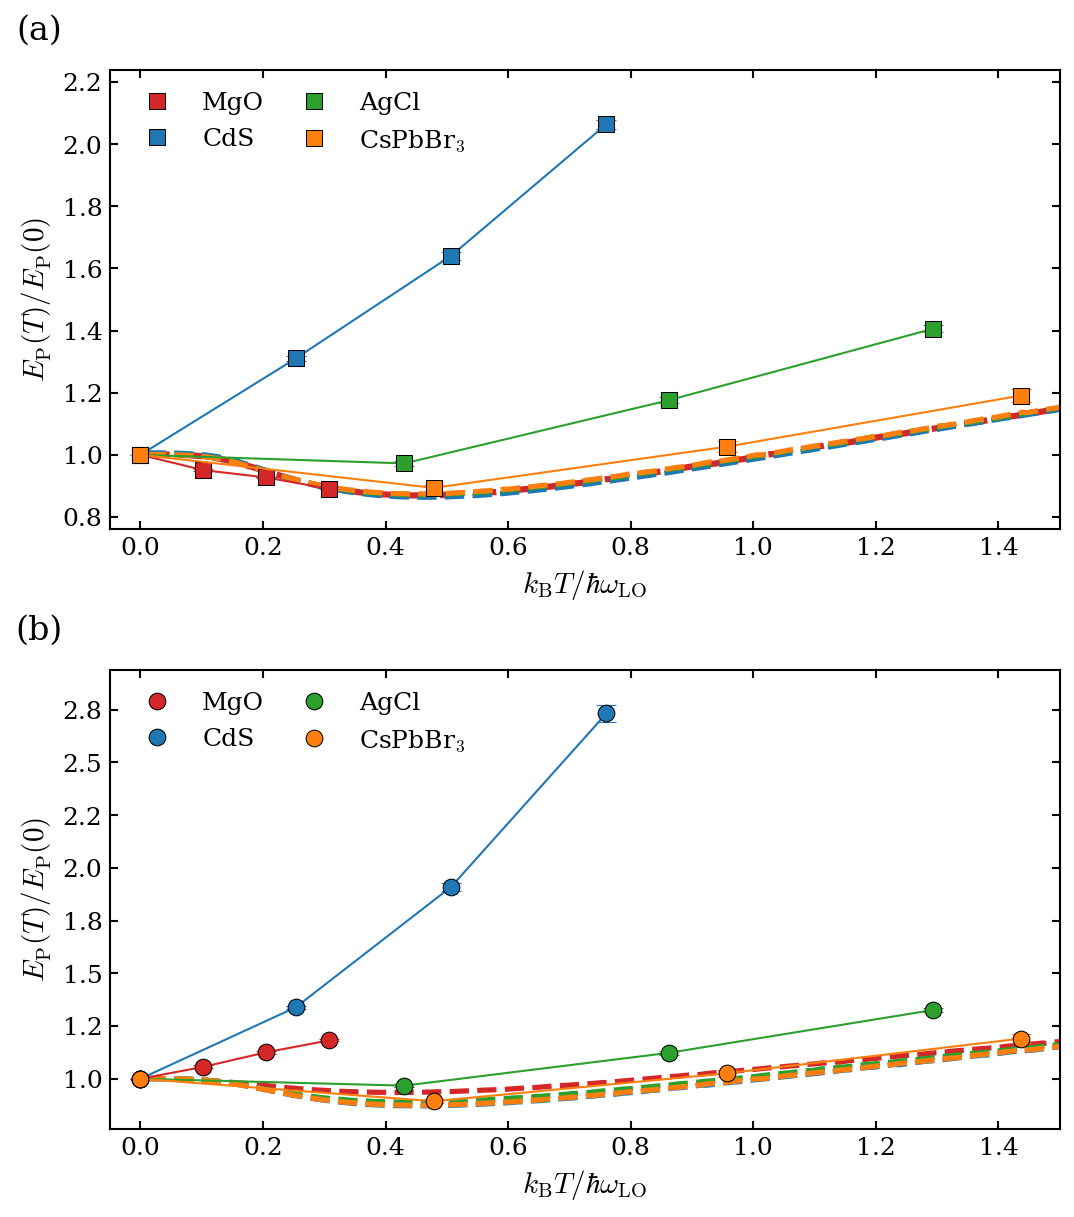

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# =============================================================================
# Plot parameters
# =============================================================================

scale = 1.0
main_text_size = 14
tick_label_size = 12
legend_size = 12
lab_size = 16

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif', 'Computer Modern Roman', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = main_text_size
plt.rcParams['axes.labelsize'] = main_text_size
plt.rcParams['xtick.labelsize'] = tick_label_size
plt.rcParams['ytick.labelsize'] = tick_label_size
plt.rcParams['legend.fontsize'] = legend_size
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.formatter.use_mathtext'] = True

# =============================================================================
# Raw PIMC Data (LO and Acoustic)
# =============================================================================

T = np.array([0, 100, 200, 300])

# AgCl
agcl_e_LO = np.array([-37.56808461, -32.44233138, -36.115628, -40.93511595])
agcl_e_err_LO = np.array([0.27805377, 0.07954199, 0.15113141, 0.15624447])
agcl_e_Ac = np.array([-0.3265399, -4.40714148, -8.4311931, -12.32174692])
agcl_e_err_Ac = np.array([0.00262231, 0.01635031, 0.04196408, 0.05741026])

agcl_h_LO = np.array([-69.89450879, -62.52060424, -69.01403767, -78.5054677])
agcl_h_err_LO = np.array([0.45181249, 0.15937162, 0.20646137, 0.35348768])
agcl_h_Ac = np.array([-0.45131815, -5.52932801, -9.95606082, -14.74086556])
agcl_h_err_Ac = np.array([0.00214326, 0.02730665, 0.05048565, 0.14263311])

# CdS
cds_e_LO = np.array([-14.75330134, -13.51113626, -12.9023934, -13.77099788])
cds_e_err_LO = np.array([0.09634742, 0.0320108, 0.06739597, 0.06484605])
cds_e_Ac = np.array([-0.60831543, -6.61447427, -12.29917973, -17.9369038])
cds_e_err_Ac = np.array([0.00325026, 0.04856863, 0.07354531, 0.0765124])

cds_h_LO = np.array([-63.35108743, -59.41266997, -61.51178788, -69.01193443])
cds_h_err_LO = np.array([0.29796446, 0.21306125, 0.3050245, 0.57391985])
cds_h_Ac = np.array([-4.98767461, -32.07520239, -68.98558006, -117.69687704])
cds_h_err_Ac = np.array([0.04900994, 0.36324878, 1.07330032, 2.66614679])

# MgO
mgo_e_LO = np.array([-133.0304164124598, -126.34241615, -122.99422926, -117.97992712])
mgo_e_err_LO = np.array([0.197, 0.31059519, 0.18669448, 0.21548494])
mgo_e_Ac = np.array([-0.16704692, -0.29540024, -0.49467159, -0.63479399])
mgo_e_err_Ac = np.array([0.00086989, 0.00243644, 0.0019532, 0.00296842])

mgo_h_LO = np.array([-601.04715512, -591.65972945, -595.78339489, -596.24002707])
mgo_h_err_LO = np.array([2.46744093, 3.3154464, 2.5949937, 1.41378953])
mgo_h_Ac = np.array([-33.51849786, -78.7143635, -118.33670057, -153.85552012])
mgo_h_err_Ac = np.array([0.32682424, 1.91392506, 1.72186727, 1.01112212])

# Perovskite (CsPbBr3)
perov_e_LO = np.array([-38.34898866, -34.25212657, -39.33401644, -45.62725523])
perov_e_err_LO = np.array([0.36047571, 0.17172323, 0.51944745, 0.63590648])
perov_e_Ac = np.array([-0.00047541, -0.01520711, -0.02992559, -0.03061016])
perov_e_err_Ac = np.array([2.5222e-07, 4.1447e-05, 0.00036461, 0.00032933])

perov_h_LO = np.array([-38.34898866, -34.25212657, -39.33401644, -45.62725523])
perov_h_err_LO = np.array([0.36047571, 0.17172323, 0.51944745, 0.63590648])
perov_h_Ac = np.array([2.5499e-06, -0.00803061, -0.01626123, -0.02362543])
perov_h_err_Ac = np.array([0.00292688, 8.8243e-05, 2.0338e-05, 0.00018786])

# =============================================================================
# Add errors
# =============================================================================

agcl_e_total = agcl_e_LO + agcl_e_Ac
agcl_e_err_total = np.sqrt(agcl_e_err_LO**2 + agcl_e_err_Ac**2)
agcl_h_total = agcl_h_LO + agcl_h_Ac
agcl_h_err_total = np.sqrt(agcl_h_err_LO**2 + agcl_h_err_Ac**2)

cds_e_total = cds_e_LO + cds_e_Ac
cds_e_err_total = np.sqrt(cds_e_err_LO**2 + cds_e_err_Ac**2)
cds_h_total = cds_h_LO + cds_h_Ac
cds_h_err_total = np.sqrt(cds_h_err_LO**2 + cds_h_err_Ac**2)

mgo_e_total = mgo_e_LO + mgo_e_Ac
mgo_e_err_total = np.sqrt(mgo_e_err_LO**2 + mgo_e_err_Ac**2)
mgo_h_total = mgo_h_LO + mgo_h_Ac
mgo_h_err_total = np.sqrt(mgo_h_err_LO**2 + mgo_h_err_Ac**2)

perov_e_total = perov_e_LO + perov_e_Ac
perov_e_err_total = np.sqrt(perov_e_err_LO**2 + perov_e_err_Ac**2)
perov_h_total = perov_h_LO + perov_h_Ac
perov_h_err_total = np.sqrt(perov_h_err_LO**2 + perov_h_err_Ac**2)

# =============================================================================
# Compute normalized values
# =============================================================================

k_B = 0.08617333262
wlo_mgo = 84
wlo_cds = 34
wlo_agcl = 20
wlo_perov = 18

def compute_normalized(T_arr, E, E_err, wlo):
    x = k_B * T_arr / wlo
    E_0 = E[0]
    E_0_err = E_err[0]
    y = E / E_0
    y_err = np.abs(y) * np.sqrt((E_err / E)**2 + (E_0_err / E_0)**2)
    y_err[0] = 0
    return x, y, y_err

# Normalized data (LO + Ac totals)
x_mgo_e, y_mgo_e, yerr_mgo_e = compute_normalized(T, mgo_e_total, mgo_e_err_total, wlo_mgo)
x_cds_e, y_cds_e, yerr_cds_e = compute_normalized(T, cds_e_total, cds_e_err_total, wlo_cds)
x_agcl_e, y_agcl_e, yerr_agcl_e = compute_normalized(T, agcl_e_total, agcl_e_err_total, wlo_agcl)
x_perov_e, y_perov_e, yerr_perov_e = compute_normalized(T, perov_e_total, perov_e_err_total, wlo_perov)

x_mgo_h, y_mgo_h, yerr_mgo_h = compute_normalized(T, mgo_h_total, mgo_h_err_total, wlo_mgo)
x_cds_h, y_cds_h, yerr_cds_h = compute_normalized(T, cds_h_total, cds_h_err_total, wlo_cds)
x_agcl_h, y_agcl_h, yerr_agcl_h = compute_normalized(T, agcl_h_total, agcl_h_err_total, wlo_agcl)
x_perov_h, y_perov_h, yerr_perov_h = compute_normalized(T, perov_h_total, perov_h_err_total, wlo_perov)


fig_width_inches = 7.05
fig = plt.figure(figsize=(fig_width_inches, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']
labels = ['MgO', 'CdS', 'AgCl', r'CsPbBr$_3$']

marker_e = 's'  # square for electrons
marker_h = 'o'  # circle for holes

# =============================================================================
# Panel (a): Electron polaron (squares)
# =============================================================================

# MgO
ax1.errorbar(x_mgo_e, y_mgo_e, yerr=yerr_mgo_e, fmt=marker_e + '-', color=colors[0],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale, linewidth=1*scale)
ax1.plot(kT_hw_range, Es_e_mgo, '--', color=colors[0], linewidth=3.0*scale) # Feynman theory from other cell

# CdS
ax1.errorbar(x_cds_e, y_cds_e, yerr=yerr_cds_e, fmt=marker_e + '-', color=colors[1],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale, linewidth=1*scale)
ax1.plot(kT_hw_range, Es_e_cds, '--', color=colors[1], linewidth=2.5*scale) # Feynman theory from other cell

# AgCl
ax1.errorbar(x_agcl_e, y_agcl_e, yerr=yerr_agcl_e, fmt=marker_e + '-', color=colors[2],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale, linewidth=1*scale)
ax1.plot(kT_hw_range, Es_e_agcl, '--', color=colors[2], linewidth=2.5*scale) # Feynman theory from other cell

# CsPbBr3
ax1.errorbar(x_perov_e, y_perov_e, yerr=yerr_perov_e, fmt=marker_e + '-', color=colors[3],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale, linewidth=1*scale)
ax1.plot(kT_hw_range, Es_e_perov, '--', color=colors[3], linewidth=2.5*scale) # Feynman theory from other cell

ax1.set_xlabel(r'$k_{\mathrm{B}} T / \hbar\omega_{\mathrm{LO}}$')
ax1.set_ylabel(r'$E_{\mathrm{P}}^{}(T) / E_{\mathrm{P}}^{}(0)$')
ax1.set_xlim(left=-0.05, right=1.5)
ax1.set_ylim(0.76, 2.24)
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

legend_handles_a = [Line2D([0], [0], marker=marker_e, color='w', markerfacecolor=colors[i],
                           markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5,
                           linestyle='None') for i in range(len(labels))]
ax1.legend(legend_handles_a, labels, loc='upper left', frameon=False, ncol=2, columnspacing=1)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes, fontsize=lab_size, va='bottom', ha='right')

# =============================================================================
# Panel (b): Hole polaron (circles)
# =============================================================================

# MgO
ax2.errorbar(x_mgo_h, y_mgo_h, yerr=yerr_mgo_h, fmt=marker_h + '-', color=colors[0],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale, linewidth=1*scale)
ax2.plot(kT_hw_range, Es_h_mgo, '--', color=colors[0], linewidth=2.5*scale) # Feynman theory from other cell

# CdS
ax2.errorbar(x_cds_h, y_cds_h, yerr=yerr_cds_h, fmt=marker_h + '-', color=colors[1],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale, linewidth=1*scale)
ax2.plot(kT_hw_range, Es_h_cds, '--', color=colors[1], linewidth=2.5*scale) # Feynman theory from other cell

# AgCl
ax2.errorbar(x_agcl_h, y_agcl_h, yerr=yerr_agcl_h, fmt=marker_h + '-', color=colors[2],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale, linewidth=1*scale)
ax2.plot(kT_hw_range, Es_h_agcl, '--', color=colors[2], linewidth=2.5*scale) # Feynman theory from other cell

# CsPbBr3
ax2.errorbar(x_perov_h, y_perov_h, yerr=yerr_perov_h, fmt=marker_h + '-', color=colors[3],
             capsize=5*scale, capthick=1.5*scale, markersize=8*scale,
             markeredgecolor='black', markeredgewidth=0.5, elinewidth=1.5*scale, linewidth=1*scale)
ax2.plot(kT_hw_range, Es_h_perov, '--', color=colors[3], linewidth=2.5*scale) # Feynman theory from other cell

ax2.set_xlabel(r'$k_{\mathrm{B}} T / \hbar\omega_{\mathrm{LO}}$')
ax2.set_ylabel(r'$E_{\mathrm{P}}^{}(T) / E_{\mathrm{P}}^{}(0)$')
ax2.set_xlim(left=-0.05, right=1.5)
ax2.set_ylim(0.76, 2.94)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

legend_handles_b = [Line2D([0], [0], marker=marker_h, color='w', markerfacecolor=colors[i],
                           markersize=8*scale, markeredgecolor='black', markeredgewidth=0.5,
                           linestyle='None') for i in range(len(labels))]
ax2.legend(legend_handles_b, labels, loc='upper left', frameon=False, ncol=2, columnspacing=1)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes, fontsize=lab_size, va='bottom', ha='right')

plt.show()